In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import chi2_contingency
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score


import warnings
warnings.filterwarnings('ignore')


cust_df = pd.read_csv("C:\\Users\\vmaru\\Desktop\\Derivatives\\customers.csv")

comp_df = pd.read_csv("C:\\Users\\vmaru\\Desktop\\Derivatives\\complaints.csv")

monthly_report_df = pd.read_csv("C:\\Users\\vmaru\\Desktop\\Derivatives\\monthly_reports.csv")

c:\Users\vmaru\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
comp_df_1 = comp_df[:] 

len(comp_df)

5576

In [4]:
vec = []

for i in range(len(comp_df_1)):
    if all(comp_df_1.loc[i,['complaint_reason', 'accountid', 'complaint_subreason']].isna()):
        pass
    else:
        vec.append(i)


In [5]:
comp_df_2 = comp_df_1.iloc[vec,]



In [6]:
comp_df_2 = comp_df_2[comp_df_2['accountid'].isna() == False]

In [7]:
def plot_case_counts(df, group_by_column, id_column='caseid', top_n=None):

    group_counts = df.groupby(group_by_column)[id_column].count().reset_index()
    group_counts = group_counts.rename(columns={id_column: 'case_count'})
    group_counts = group_counts.sort_values(by='case_count', ascending=False)
    
    if top_n:
        group_counts = group_counts.head(top_n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=group_counts, x='case_count', y=group_by_column, palette='viridis')
    plt.title(f'Number of Cases per {group_by_column}')
    plt.xlabel('Number of Cases')
    plt.ylabel(group_by_column.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()


We observed that the majority of complaints are generated by the Credit Team, leading to a significant class imbalance among complaint categories. This imbalance poses a challenge for machine learning models:
If we attempt to classify each category individually, the model is likely to favor the majority class and fail to correctly identify smaller groups, misclassifying them as the dominant class.

To address this issue, we propose grouping the complaint reasons into two broader categories. This binary classification approach simplifies the task and helps the model better distinguish between major vs. minor complaint types, improving overall performance and interpretability.



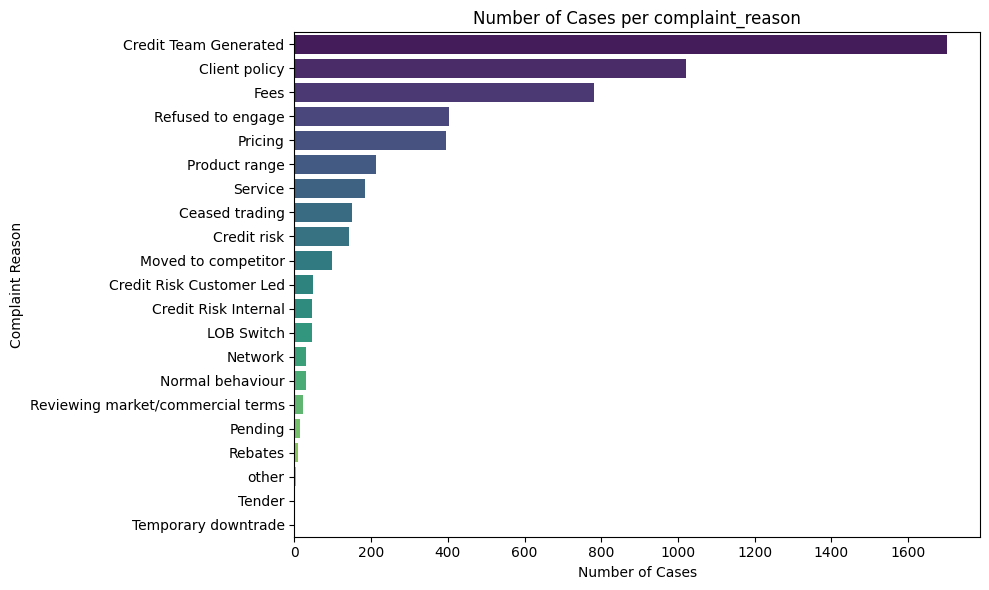

In [8]:
plot_case_counts(comp_df_2, 'complaint_reason')

In [9]:
comp_df_2['createddate'] = pd.to_datetime(comp_df_2['createddate'])

comp_df_2['dates'] = comp_df_2['createddate'].dt.date

comp_df_2['hours'] = comp_df_2['createddate'].dt.hour

comp_df_2['weekday'] = comp_df_2['createddate'].dt.dayofweek


We observed a notable anomaly in the distribution of complaint creation dates. Specifically, the following dates show an unusually high volume of complaints: 2024-07-29, 2024-08-06, 2024-08-15, 2024-08-23, 2024-08-27, 2024-09-02, 2024-09-09, 2024-10-16, 2024-10-17.

On each of these dates, the number of complaints exceeded 100 cases, while the median daily complaint volume is approximately 22. This suggests a significant deviation from typical patterns and may indicate that specific events or operational issues occurred on those days that triggered a surge in customer dissatisfaction.

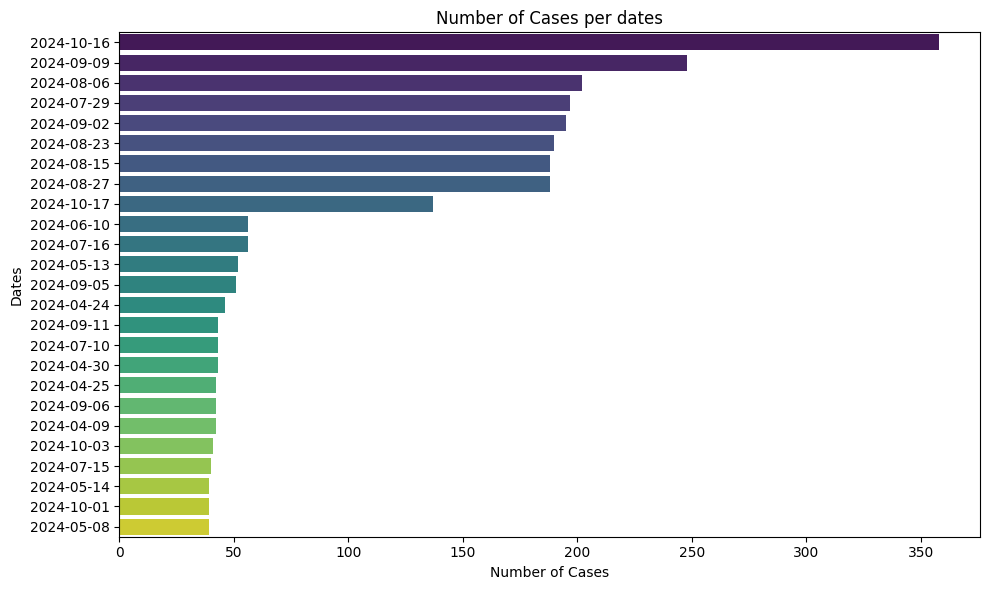

In [10]:


plot_case_counts(comp_df_2, 'dates', top_n= 25)

We observed that a large portion of complaints are submitted around 08:00 and 13:00. This temporal pattern may be driven by customer behavior and internal operations:

08:00 spike: This likely corresponds with the opening time of customer support. Customers may be attempting to resolve their issues as early as possible, especially if they experienced problems overnight or need assistance before the workday begins.

13:00 spike: This aligns with typical lunch hours, when customers may finally have free time during the day to report issues. Alternatively, it may reflect midday service disruptions or operational triggers that negatively affect customer experience around this time.

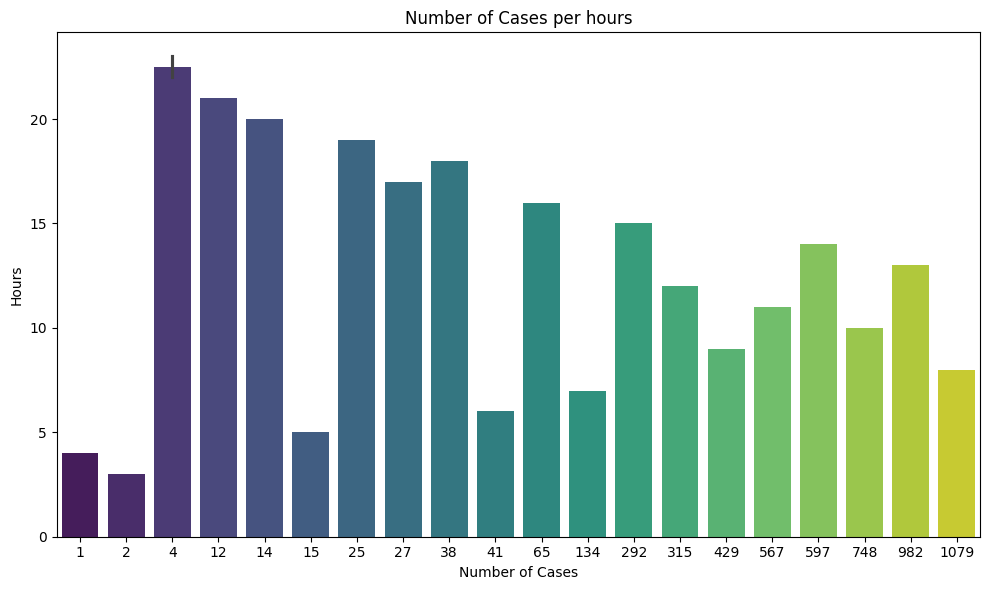

In [11]:
plot_case_counts(comp_df_2, 'hours')

The weekday variable shows limited variability and does not provide strong predictive value on its own. Nearly all complaints are submitted during business days, with very few occurring on weekends.

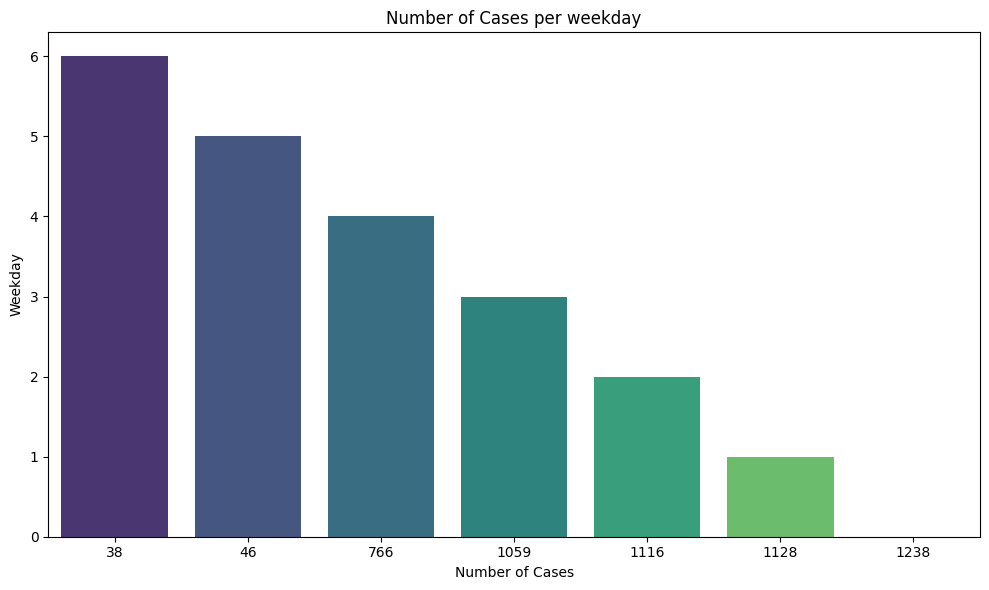

In [12]:
plot_case_counts(comp_df_2, 'weekday')

In [13]:
df_1 = comp_df_2.merge(cust_df[['accountid', 'customerid']], on = 'accountid')

df_1.drop_duplicates()


df_1 = df_1.merge(monthly_report_df, on = 'customerid')


df_1 = df_1.drop_duplicates()


In [14]:
all_ids = set(monthly_report_df['customerid'].dropna().unique())

for i in range(len(monthly_report_df)):
    if monthly_report_df['customerid'].isna()[i]:
        k = random.choice(list(set(range(20000)) - all_ids))
        all_ids.add(k)
        monthly_report_df['customerid'][i] = k




In [15]:
monthly_report_df['customerid'].isna().sum()


np.int64(0)

In [16]:
df_not_comp = monthly_report_df[~monthly_report_df['customerid'].isin(df_1['customerid'])]

In [17]:
label_for_vis = list(df_not_comp.columns)
label_for_vis.remove('customerid')
label_for_vis.remove('report_month')

In [18]:
def plot_trimmed_distributions(series1, series2, label1='Series 1', label2='Series 2', alpha=0.5, ax=None):

    s1 = np.asarray(series1)
    s2 = np.asarray(series2)

    # 95% confidence interval
    if len(s1) < 2 or len(s2) < 2:
        return  # skip if not enough data

    low1, high1 = np.percentile(s1, [2.5, 97.5])
    low2, high2 = np.percentile(s2, [2.5, 97.5])

    trimmed1 = s1[(s1 >= low1) & (s1 <= high1)]
    trimmed2 = s2[(s2 >= low2) & (s2 <= high2)]

    if len(trimmed1) == 0 or len(trimmed2) == 0:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        return
    
    sns.kdeplot(trimmed1, label=label1, color='steelblue', fill=True, alpha=alpha, linewidth=2, ax=ax)
    sns.kdeplot(trimmed2, label=label2, color='darkorange', fill=True, alpha=alpha, linewidth=2, ax=ax)

    ax.set_ylabel('Density')
    ax.set_xlabel('')
    ax.legend()
    ax.grid(True)


In [19]:
def plot_distributions_grid(df1, df2, label_for_vis, label1='df1', label2='df2', alpha=0.5, max_cols=2):
    import math
    import matplotlib.pyplot as plt

    n = len(label_for_vis)
    n_cols = max_cols
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(label_for_vis):
        if col not in df1.columns or col not in df2.columns:
            axes[i].text(0.5, 0.5, f'Missing: {col}', ha='center', va='center')
            axes[i].set_axis_off()
            continue

        try:
            plot_trimmed_distributions(
                df1[col].dropna(),
                df2[col].dropna(),
                label1=label1,
                label2=label2,
                alpha=alpha,
                ax=axes[i]
            )
            axes[i].set_title(f'{col} (95% CI)')
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center')
            axes[i].set_axis_off()

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In this step, we examine how the distributions of various features differ between two groups of clients:
- Clients who submitted a complaint
- Clients who did not submit a complaint

Such features are valuable for predictive modeling, as they may help the model distinguish between customers likely to complain and those who are not.

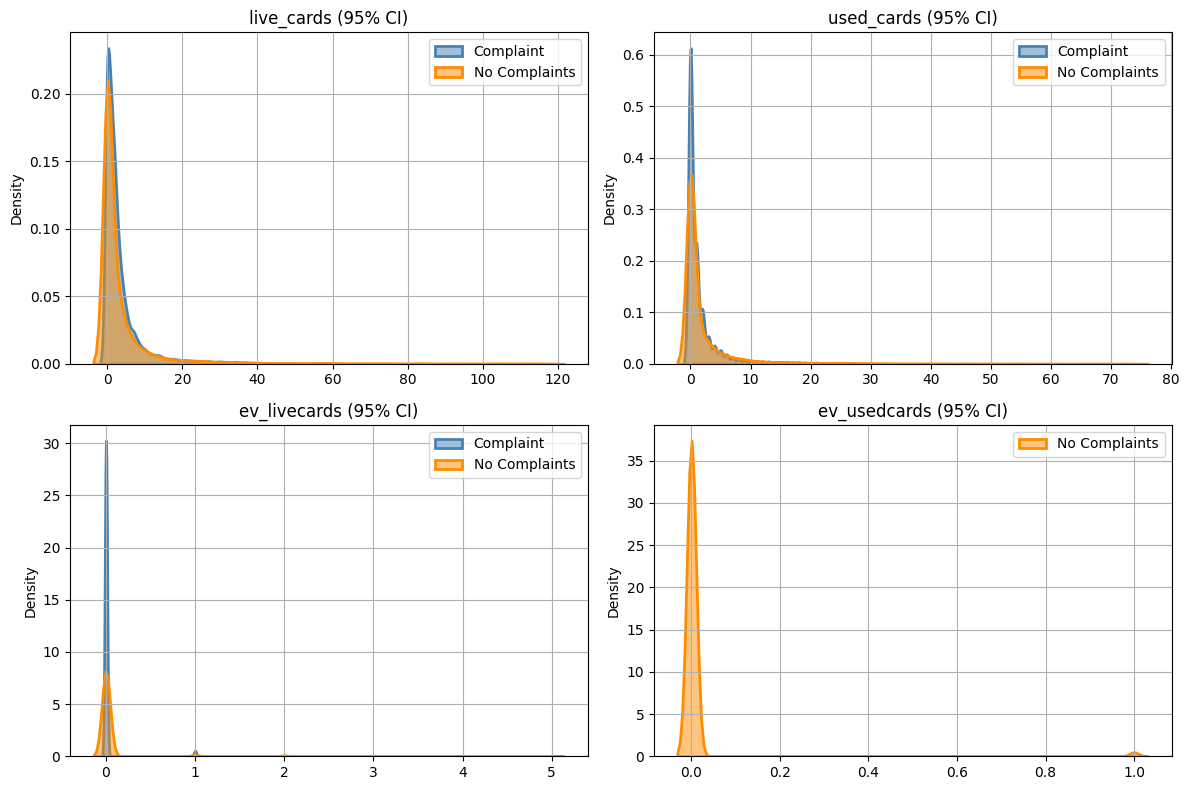

In [20]:
plot_distributions_grid(
    df1 = df_1,
    df2 = df_not_comp,
    label_for_vis= label_for_vis[:4],
    label1='Complaint',
    label2='No Complaints',
    max_cols=2
)

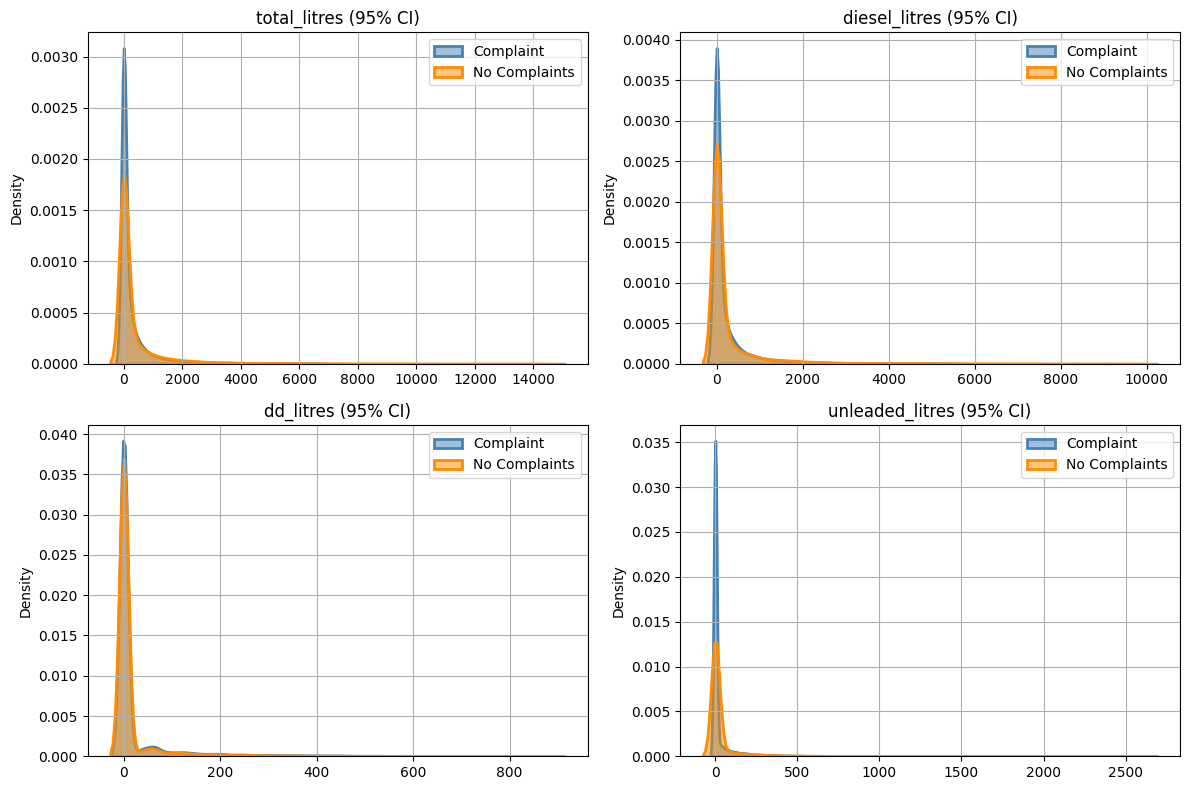

In [21]:
plot_distributions_grid(
    df1 = df_1,
    df2 = df_not_comp,
    label_for_vis= label_for_vis[4:8],
    label1='Complaint',
    label2='No Complaints',
    max_cols=2
)

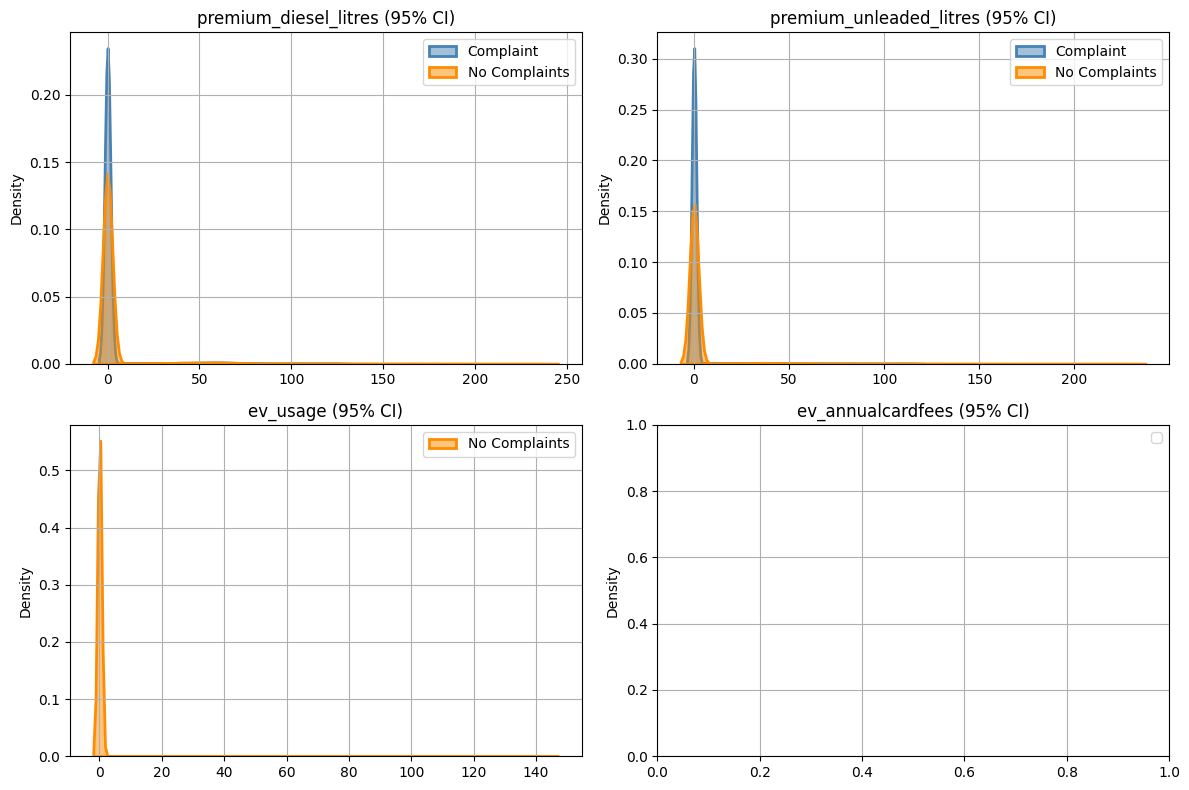

In [22]:
plot_distributions_grid(
    df1 = df_1,
    df2 = df_not_comp,
    label_for_vis= label_for_vis[8:12],
    label1='Complaint',
    label2='No Complaints',
    max_cols=2
)

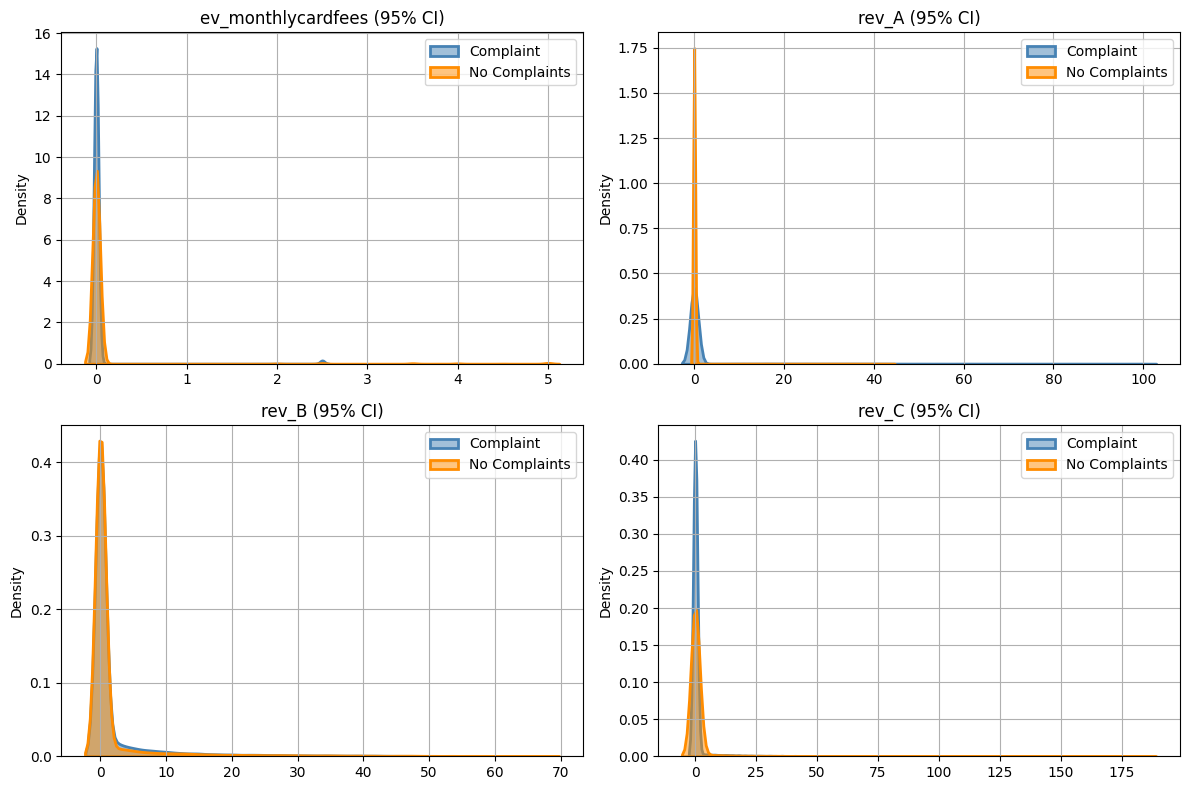

In [23]:
plot_distributions_grid(
    df1 = df_1,
    df2 = df_not_comp,
    label_for_vis= label_for_vis[12:16],
    label1='Complaint',
    label2='No Complaints',
    max_cols=2
)

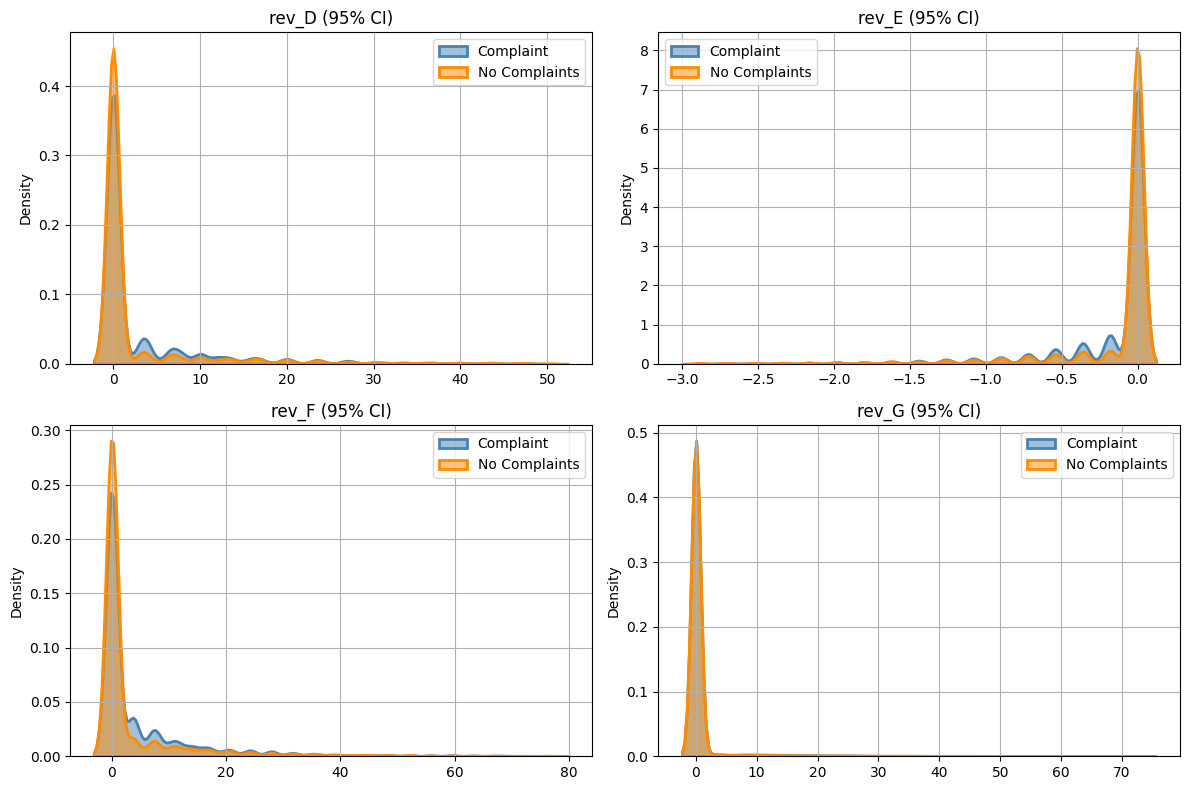

In [24]:
plot_distributions_grid(
    df1 = df_1,
    df2 = df_not_comp,
    label_for_vis= label_for_vis[16:20],
    label1='Complaint',
    label2='No Complaints',
    max_cols=2
)

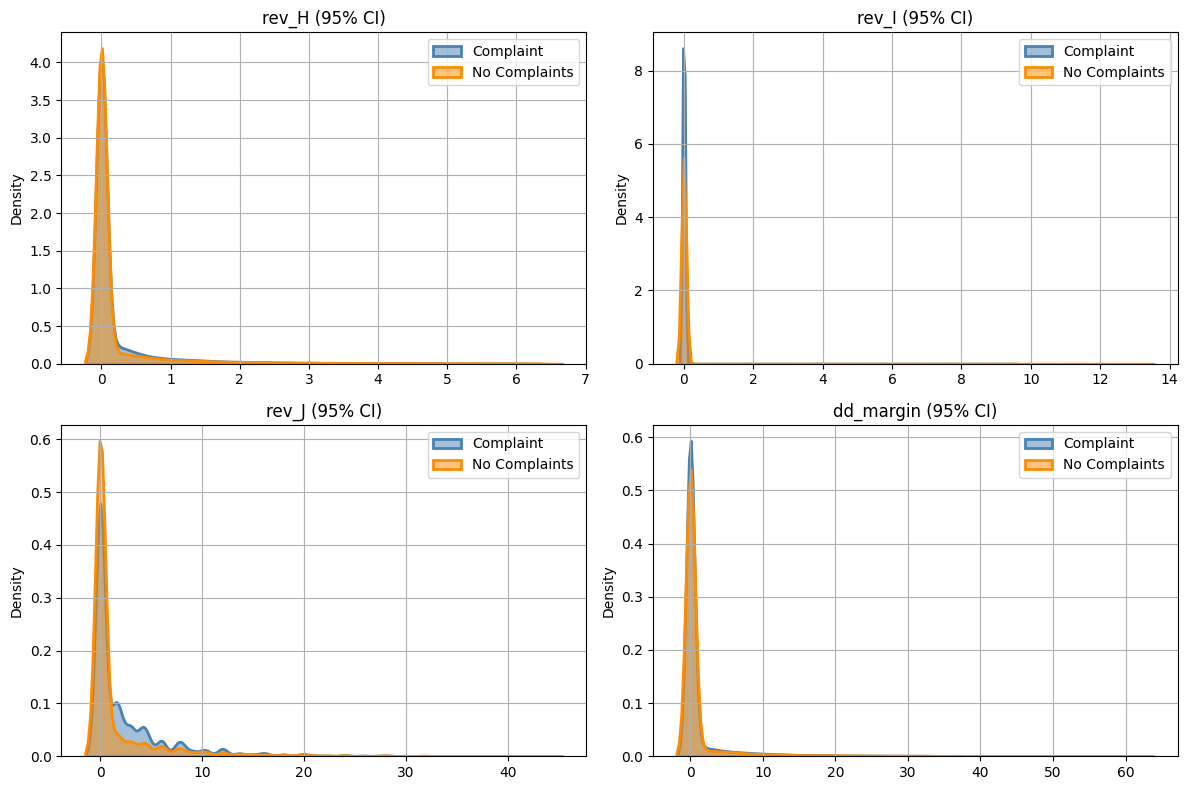

In [25]:
plot_distributions_grid(
    df1 = df_1,
    df2 = df_not_comp,
    label_for_vis= label_for_vis[20:24],
    label1='Complaint',
    label2='No Complaints',
    max_cols=2
)

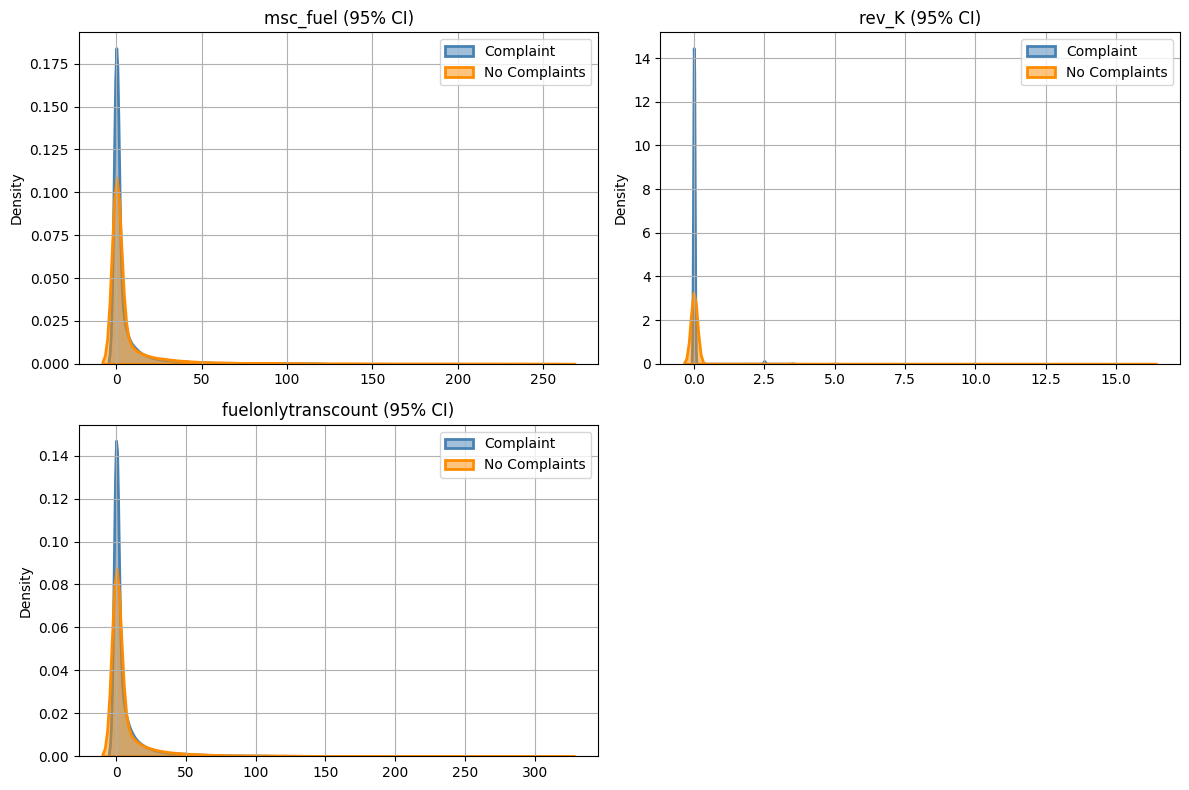

In [26]:
plot_distributions_grid(
    df1 = df_1,
    df2 = df_not_comp,
    label_for_vis= label_for_vis[24:],
    label1='Complaint',
    label2='No Complaints',
    max_cols=2
)

I will automatically group text reasons into two semantic clusters using embeddings (OpenAI or Sentence Transformers) to convert text into vectors. Then, using Agglomerative clustering, I will distribute the reasons into clusters based on the semantic proximity of the vectors. 


In [27]:
reasons = [
    'Pricing', 'Fees', 'Rebates', 'Credit risk', 'Credit Risk Customer Led',
    'Credit Risk Internal', 'Credit Team Generated', 'Moved to competitor',
    'Client policy', 'Tender', 'Reviewing market/commercial terms',
    'Refused to engage', 'Normal behaviour', 'Product range', 'LOB Switch',
    'Temporary downtrade', 'Service', 'Network', 'Ceased trading',
    'Pending', 'other'
]

# 1. Встраивания (embeddings)
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(reasons)

# 2. Кластеризация
kmeans = AgglomerativeClustering(n_clusters=2)
labels = kmeans.fit_predict(embeddings)

# 3. Вывод результата
reason_df = pd.DataFrame({'reason': reasons, 'cluster': labels})
print(reason_df.sort_values('cluster'))


                               reason  cluster
0                             Pricing        0
1                                Fees        0
2                             Rebates        0
7                 Moved to competitor        0
11                  Refused to engage        0
10  Reviewing market/commercial terms        0
9                              Tender        0
8                       Client policy        0
12                   Normal behaviour        0
13                      Product range        0
14                         LOB Switch        0
15                Temporary downtrade        0
19                            Pending        0
18                     Ceased trading        0
17                            Network        0
16                            Service        0
20                              other        0
4            Credit Risk Customer Led        1
5                Credit Risk Internal        1
6               Credit Team Generated        1
3            

Based on the previous step, we obtained two clusters, which we will subsequently use as a target variable. 

### Cluster 0 — Customer and market reasons

This cluster includes reasons related to customer decisions, market conditions, changing needs, or service levels. Reasons why the client or market is the initiator of changes. These may include internal client decisions, switching to other suppliers, changes in preferences, or service quality assessments.

### Cluster 1 — Internal credit reasons

This cluster combines reasons related to internal credit policy or risk management on the part of the company. The reasons why the company is initiating the changes are based on credit risk assessment or internal rules.

In [28]:
reason_cluster_map = {k:i for i,k in zip(list(reason_df['cluster']), list(reason_df['reason']))}

df_1['reason_cluster'] = df_1['complaint_reason'].map(reason_cluster_map)

In this bar plot, we can see that our classes are distributed somewhat evenly. However, 'Market Reasons' has more observations at the 20% level compared to 'Financial Reasons'. This is useful to know for future classification, as we can assume the model shouldn't favor one class simply because it has a slight majority of observations.



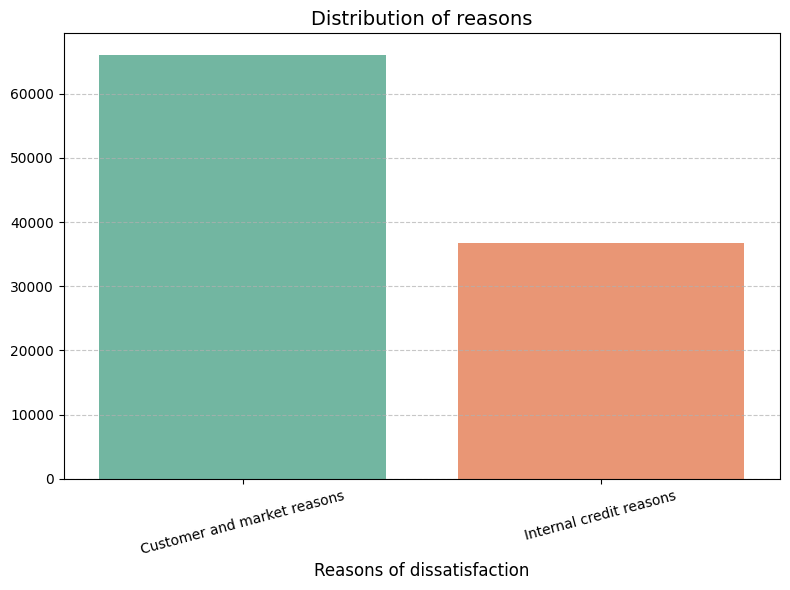

In [29]:
cluster_counts = df_1['reason_cluster'].value_counts().sort_index()

cluster_labels = {0: "Customer and market reasons", 1: "Internal credit reasons"}


plt.figure(figsize=(8, 6))
sns.barplot(
    x=cluster_counts.index.map(cluster_labels), 
    y=cluster_counts.values, 
    palette='Set2'
)

plt.title("Distribution of reasons", fontsize=14)
plt.xlabel("Reasons of dissatisfaction", fontsize=12)
plt.ylabel("", fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


After joining our datasets, we now have information about every transaction made by each customer. However, for the purposes of prediction, we don't want to include the same customer multiple times since that may confuse the classification model, especially if the same customer ends up in both the training and test sets; this could lead to data leakage, which could lead to overfitting.

Instead, I reduced the data to the median of each customer's transactions by their customer ID.

Also, I dropped all of the missing values from the target variable. We will replace them later in the project, after modeling.

In [30]:
target = 'reason_cluster'

df = df_1[:]
exclude_cols = ['caseid', 'createddate', 'closeddate', 
                'complaint_reason', 'complaint_subreason', 'dates', 
                'customerid', 'reason_cluster', 'report_month']

features = [col for col in df.columns if col not in exclude_cols]

y = df[['accountid', 'reason_cluster']].dropna().groupby('accountid').last()

X = df[features].groupby('accountid').median()

X = df[features].groupby('accountid').median()

X = X.loc[y.index]

X = X.reset_index(drop=True)
y = y['reason_cluster'].reset_index(drop=True)


This section of code was written specifically to calculate Cramér's V to assess the relationship between a specific category of our target variable and the features. We first use one-hot encoding for the target category, and then calculate the contingency between the category and each feature individually. 


In [31]:
def cramers_v(conf_matrix):
    chi2 = chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = conf_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

def calculate_cramers_v_matrix(df, target_col, features):
    # 1. One-hot encode the target column
    ohe = OneHotEncoder(drop=None)
    target_ohe = ohe.fit_transform(df[[target_col]]).toarray()
    ohe_cols = ohe.get_feature_names_out([target_col])
    target_df = pd.DataFrame(target_ohe, columns=ohe_cols, index=df.index)

    result = pd.DataFrame(index=ohe_cols, columns=features)

    for target_class in ohe_cols:
        for feature in features:
            # Only for categorical or discretized numerical variables
            contingency_table = pd.crosstab(target_df[target_class], df[feature])
            try:
                result.loc[target_class, feature] = cramers_v(contingency_table)
            except:
                result.loc[target_class, feature] = np.nan

    return result.astype(float)

X_cols = list(X.columns)

cramers_table = calculate_cramers_v_matrix(df, 'complaint_reason', X_cols)


In this step we also developed a matrix to illustrate the output from the previous step. We observe that total_liters, diesel_liters, and most of the other variables related to volume of fuel are well associated with almost all the variables.

Another interesting observation is that we noticed that the hours variable is correlated with category complaint_reason_credit_risk_internal. This suggests that complaints related to this reason were more likely to be submitted at specific times of the day.


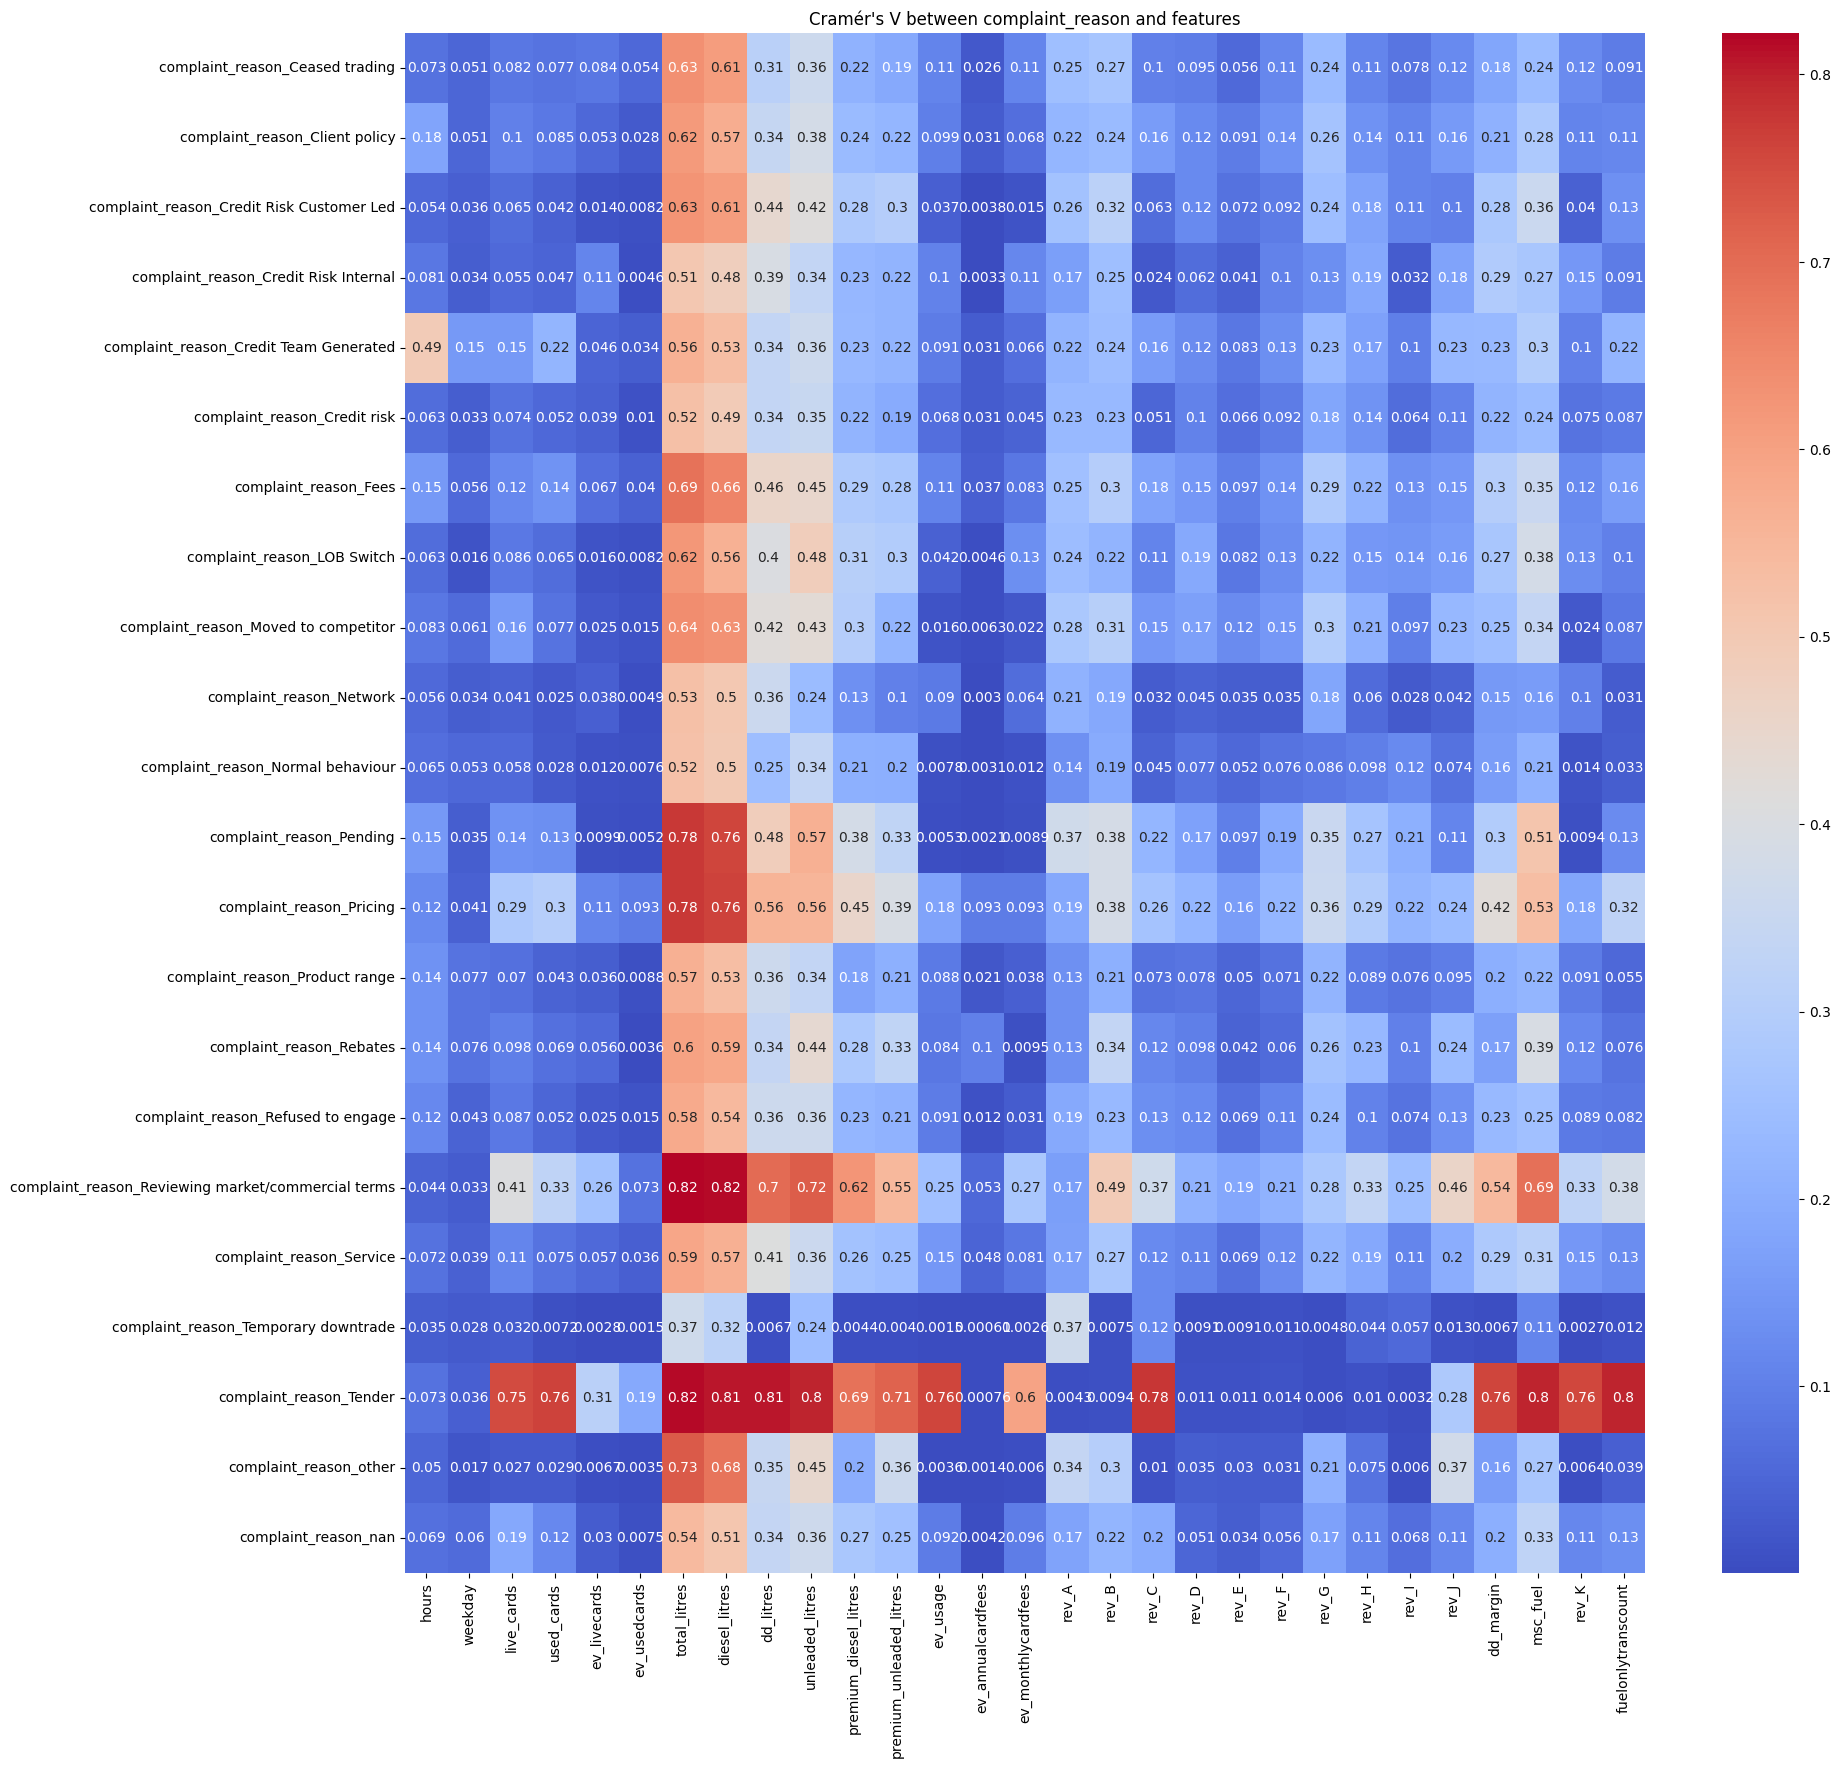

In [32]:
plt.figure(figsize=(20, 20))
sns.heatmap(cramers_table, annot=True, cmap='coolwarm')
plt.title("Cramér's V between complaint_reason and features")
plt.show()


In this section, we calculating mutual information to find the variables which distinguish between different classes of our target variable the best.

This measure is based on classic probability theory. It compares the joint distribution of two variables to the product of their marginals and uses the log of that ratio.

The ratio equals 1 means when you take the log it equals 0, which implies perfect independence of the two variables. For our purposes, we are most interested in variables with high mutual information with the targets — that is, variables that are really collinear, which will be useful for prediction.

$${I}_{(X;Y)}=\sum _{y\in {\mathcal {Y}}}\sum _{x\in {\mathcal {X}}}{P_{(X,Y)}(x,y)\log \left({\frac {P_{(X,Y)}(x,y)}{P_{X}(x)\,P_{Y}(y)}}\right)}$$


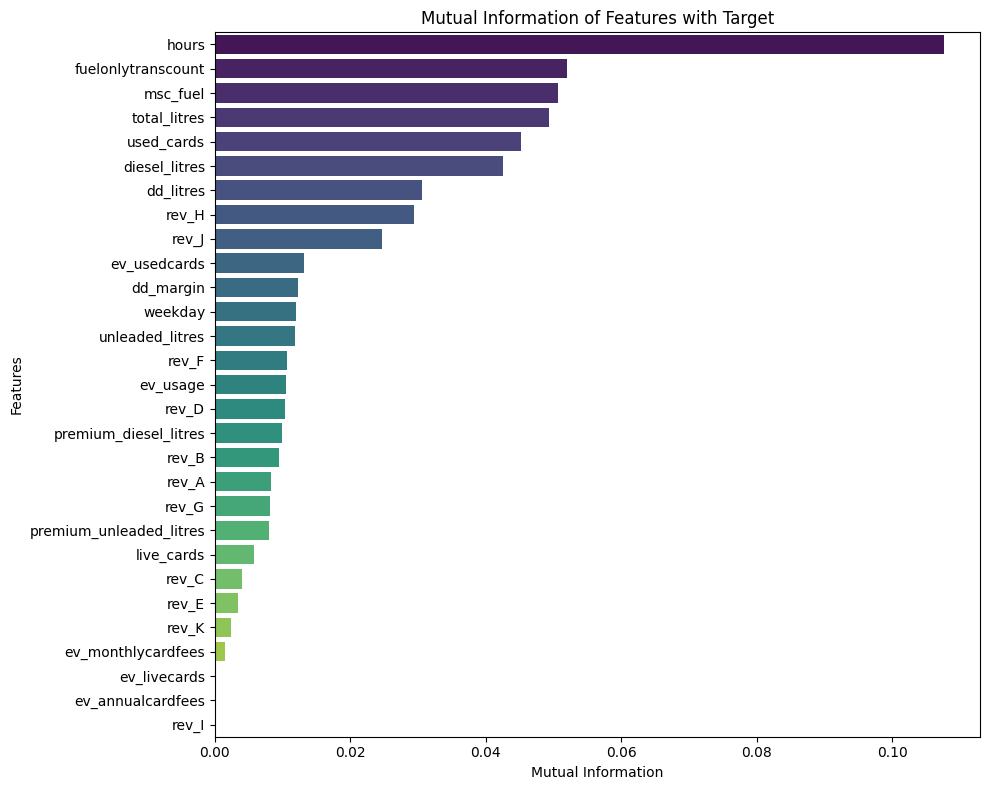

In [33]:
mi = mutual_info_classif(X, y, discrete_features='auto', random_state=42)

# Создаем DataFrame для удобства визуализации
mi_df = pd.DataFrame({
    'feature': X.columns,
    'mutual_info': mi
}).sort_values(by='mutual_info', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='mutual_info', y='feature', data=mi_df, palette='viridis')
plt.xlabel('Mutual Information')
plt.ylabel('Features')
plt.title('Mutual Information of Features with Target')
plt.tight_layout()
plt.show()


This section is directed toward correlation analysis between variables. As we can see from the previous section there are many highly correlated pairs amongst our features (X variables).

We will aim to mitigate this issue, as multicollinearity can cause overfitting and hinder our ability to determine the real effect of individual features. In an optimal scenario, direct correlations could have been addressed in a preprocessing step prior to modeling.

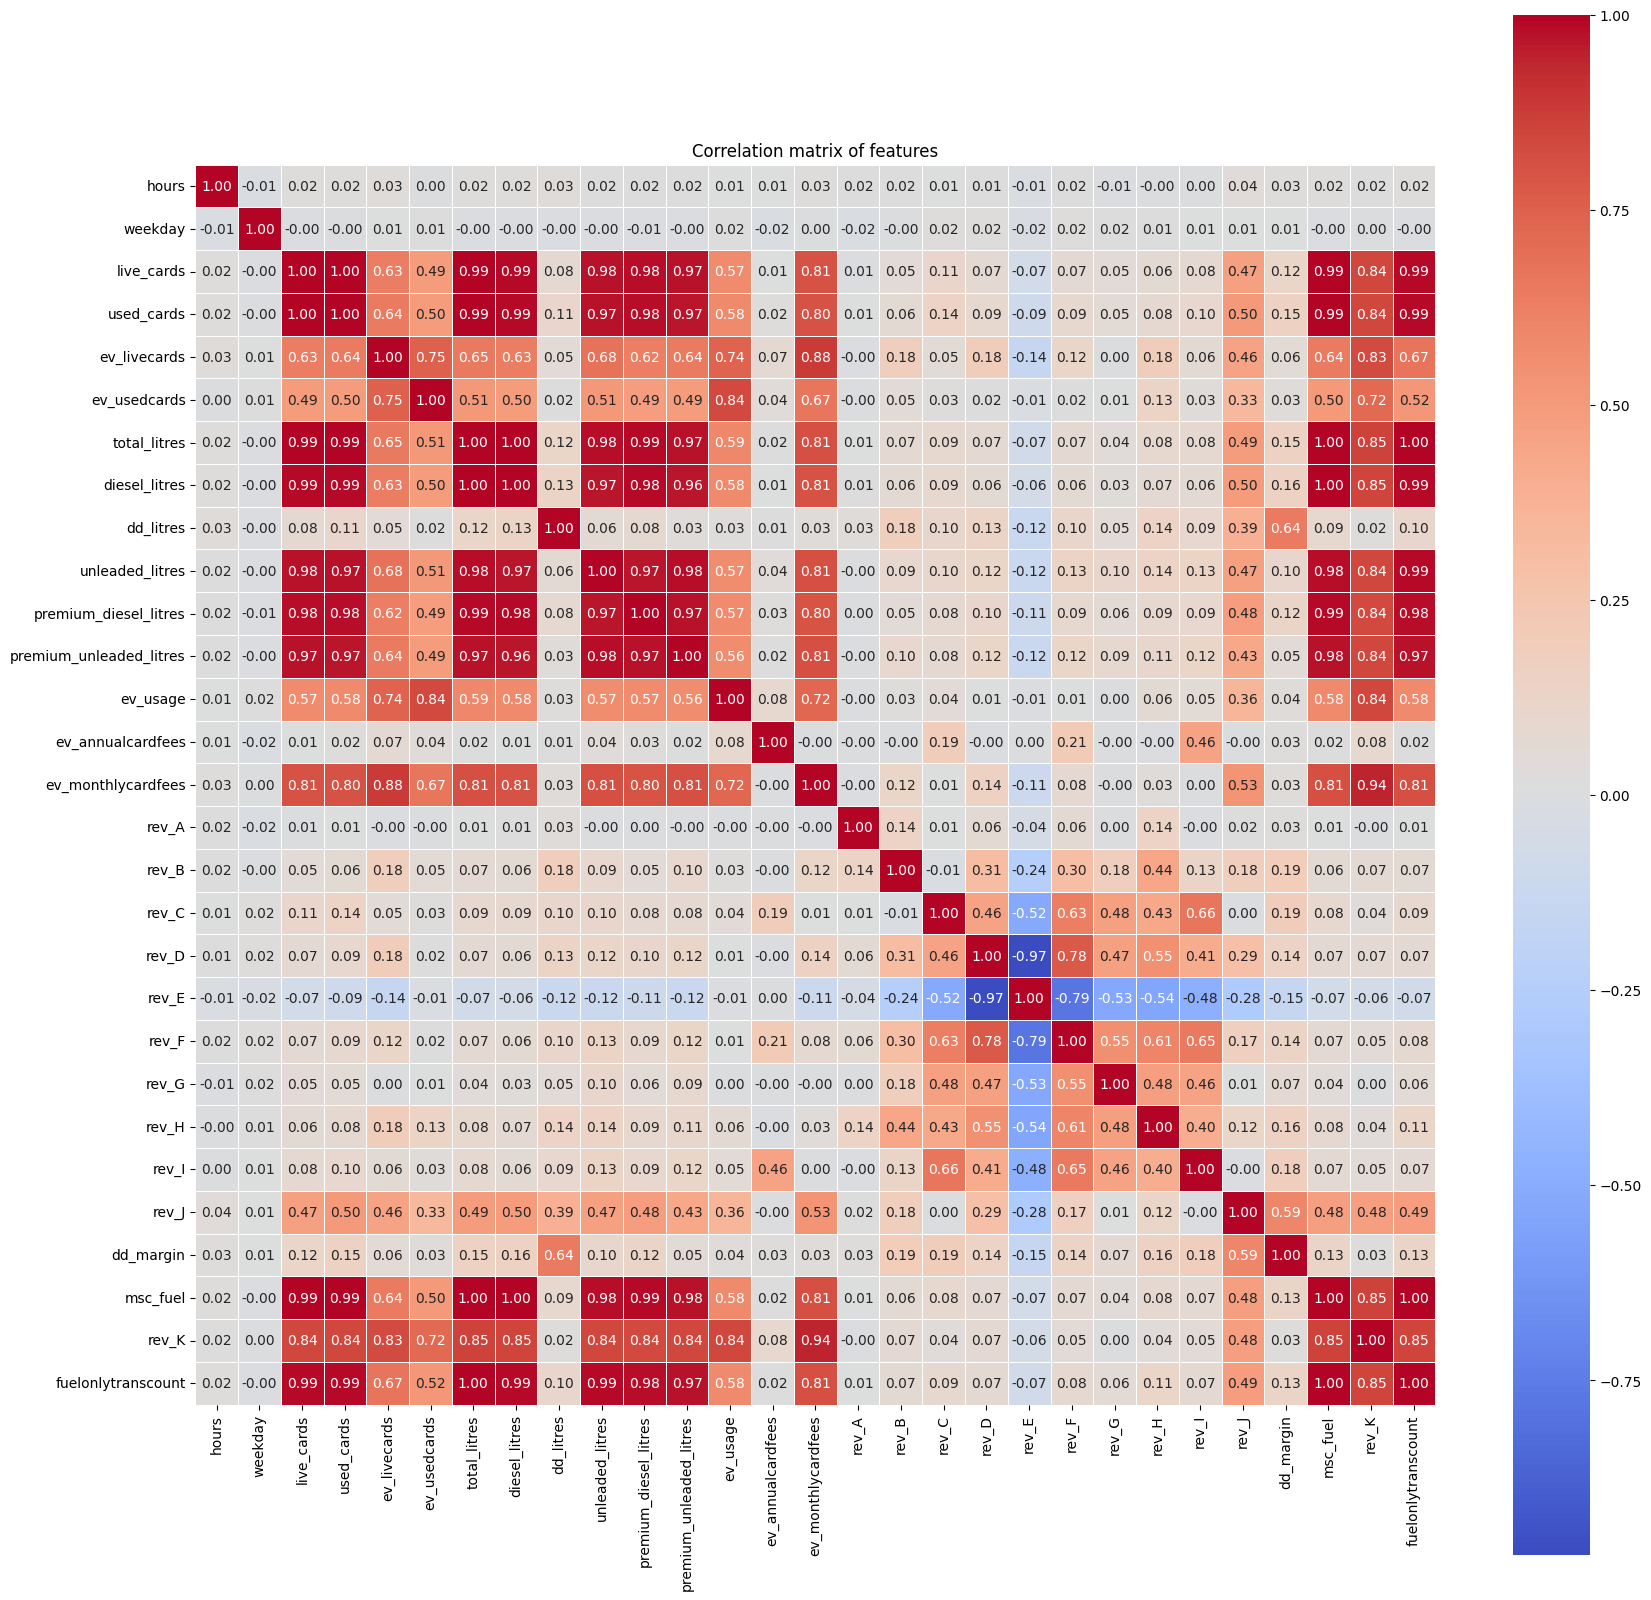

In [34]:
corr = X.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation matrix of features")
plt.show()


I used principal component analysis to reduce multicollinearity and simplify the model. PCA is useful for separating correlated features into fewer uncorrelated components. Prior to implementing PCA, I performed normalizing scaling, because PCA is sensitive to the magnitudes of features — unscaled data can skew the PCA results.

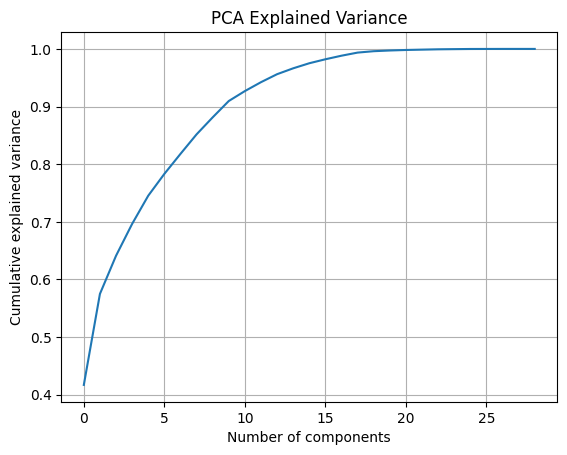

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_1 = PCA().fit(X_scaled)
plt.plot(np.cumsum(pca_1.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

The plot of cumulative explained variance indicates how many components add information. I used the elbow method to determine to use 9 components, as the curve has begun to flatten, meaning each additional component will add less new explained variance. This gives us a compact, information-rich representation of the previous data.


In [36]:
n = 9


pca = PCA(n_components= n)  # Keep 95% of variance

X_pca = pd.DataFrame(pca.fit_transform(X_scaled))
components = pca.components_

explained_variance = pca.explained_variance_ratio_
print("Explained variance per component:", *explained_variance)
print("Total explained variance:", explained_variance.sum())


Explained variance per component: 0.4169801801108415 0.15792799215989076 0.06620161382249082 0.05529741944201093 0.04889915426684217 0.03783430454214992 0.03468402304875714 0.033904727055869714 0.02948808775881712
Total explained variance: 0.88121750220767


This heatmap shows the PCA component loadings. The PCA component loadings show how each original feature contributes into the first nine principal components. Each row is a principal component (PC1, PC2, PC3, PC4, PC5, PC6, PC7, PC8, PC9), each column is an original feature. 

From the plot, PC1 appears to be influenced by a broad set of variables: weekday, fleet_card, some fuel-related features like total_liters and diesel_liters, and complaint category rev_B. This leads us to speculate that PC1 is tracking fairly generalized transactional expectation as a function of all these influencing variables. 

After PC1, PC6 and PC7 are driven mainly from complaint categories (rev_A, rev_B, rev_C) variables while having weekday and fleet_card variables as part of their structure. The contribution from the complaint categories suggest that PC6 and PC7 are tracking behavioral or complaint-related components of the principal components factor space. 

For PC3, PC4, and PC5 individual components show more moderate contribution levels from several complaint categories and suggest that these principal components capture the variance in nuanced reasons from the customers. Overall, this plot gives us important information to interpret the shape of the PCA transformation and to inform us which features are the most valuable in the components.

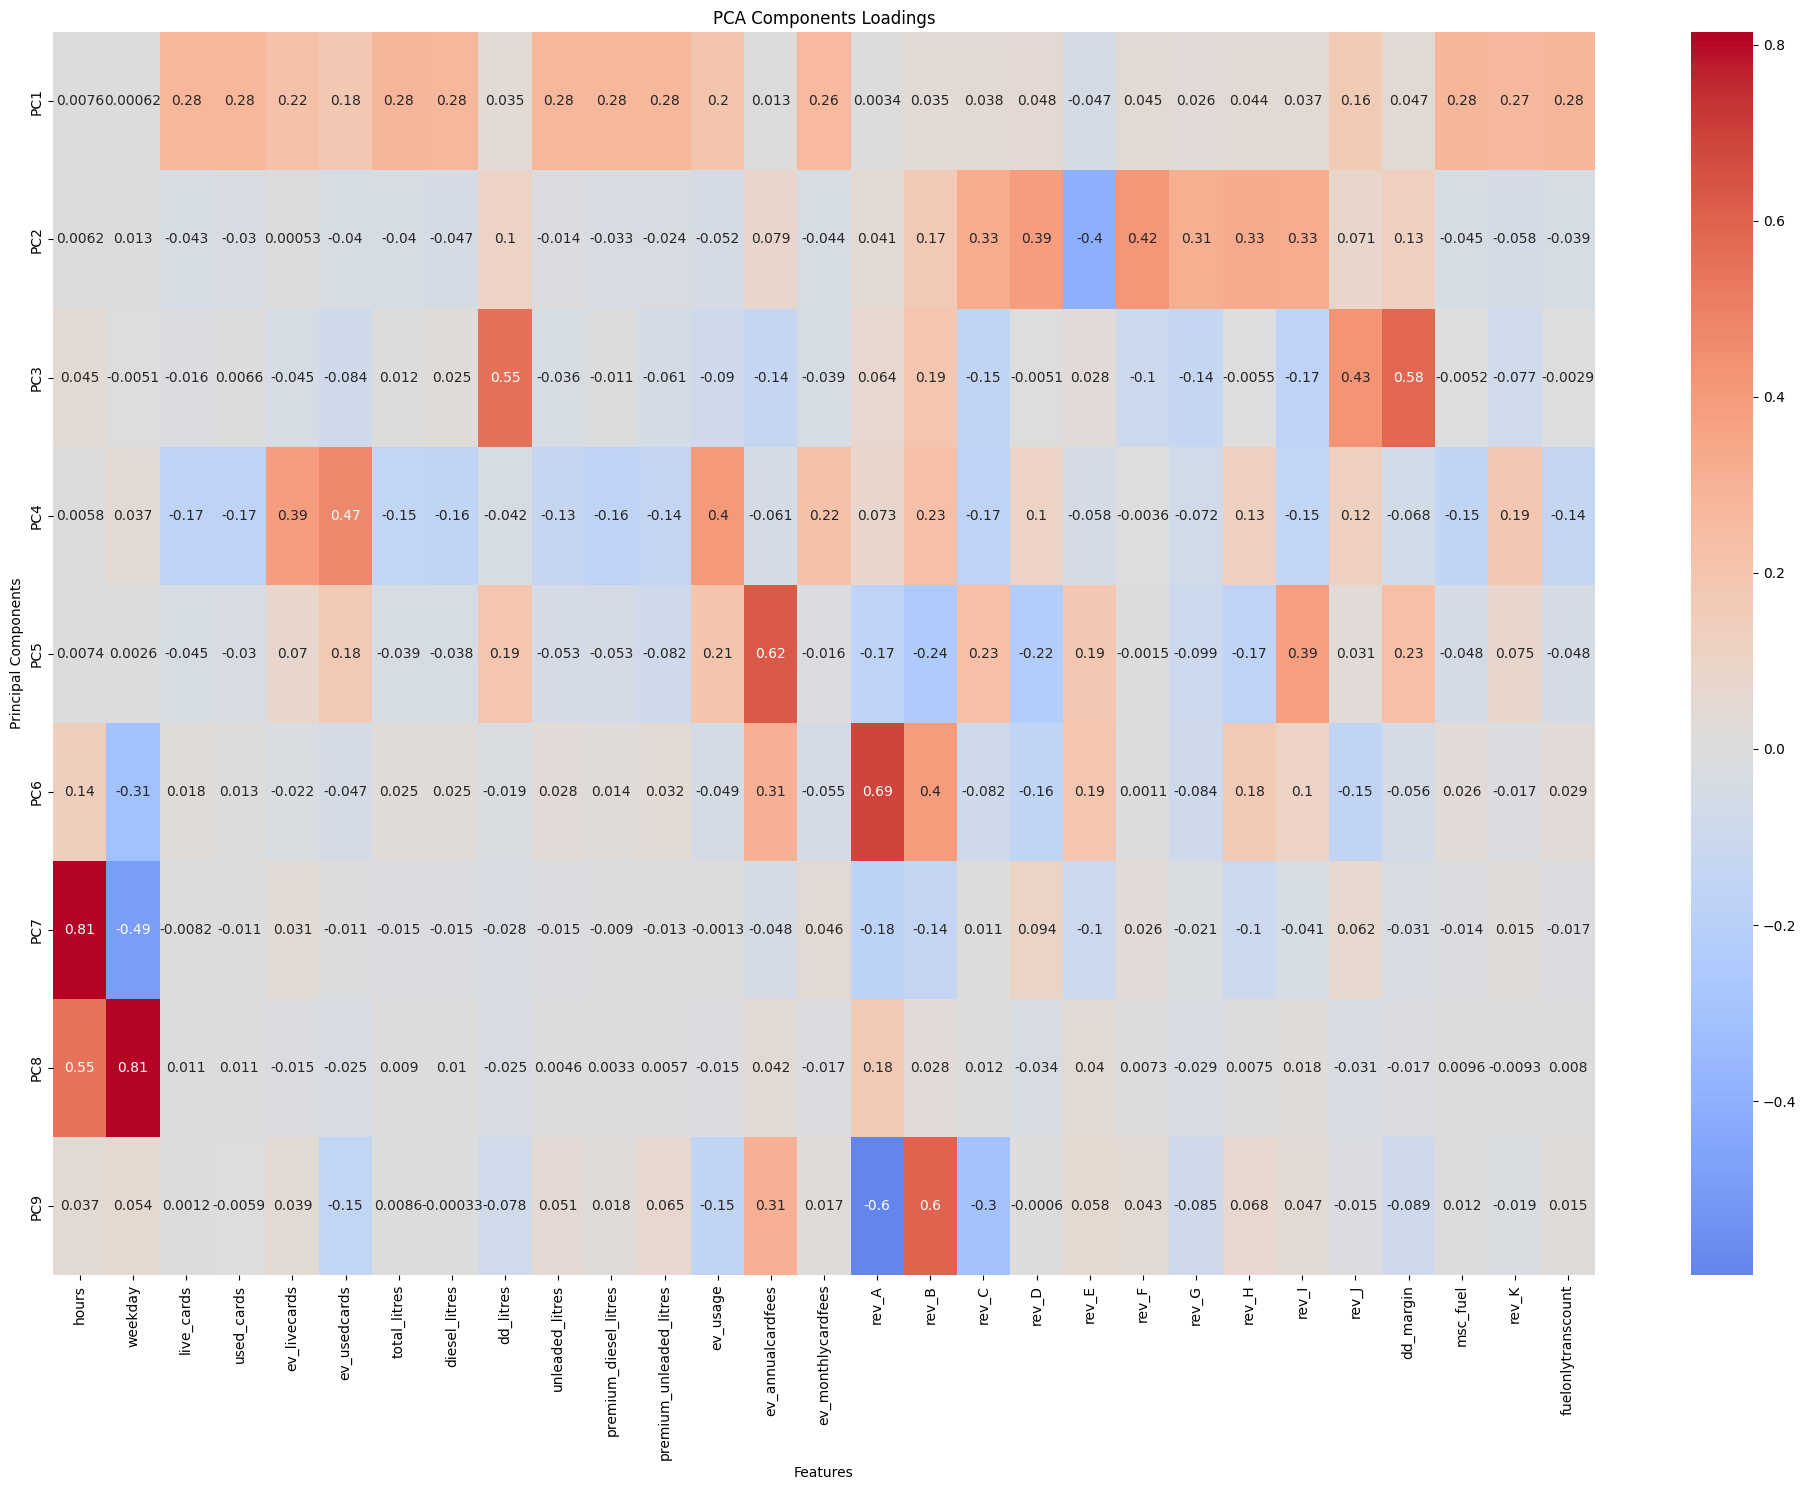

In [37]:
pca_df = pd.DataFrame(
    components,
    columns = X.columns,
    index=[f'PC{i+1}' for i in range(n)]
)

pca_df_sorted = pca_df.apply(lambda x: x.abs().sort_values(ascending=False), axis=1)

plt.figure(figsize=(20, 15))
sns.heatmap(pca_df, cmap='coolwarm', annot=True, center=0)
plt.title('PCA Components Loadings')
plt.xlabel('Features')
plt.ylabel('Principal Components')
plt.tight_layout()
plt.show()

After applying PCA, we checked the mutual information (MI) with our target again to see how things had shifted. Turns out, the MI values are higher now, and each principal component has at least a 0.1 MI score.

This tells us that these changed components are more informative than the original features. Basically, PCA didn't just help with reducing the number of features and tackling multicollinearity — it also made the features more relevant in predicting our target.

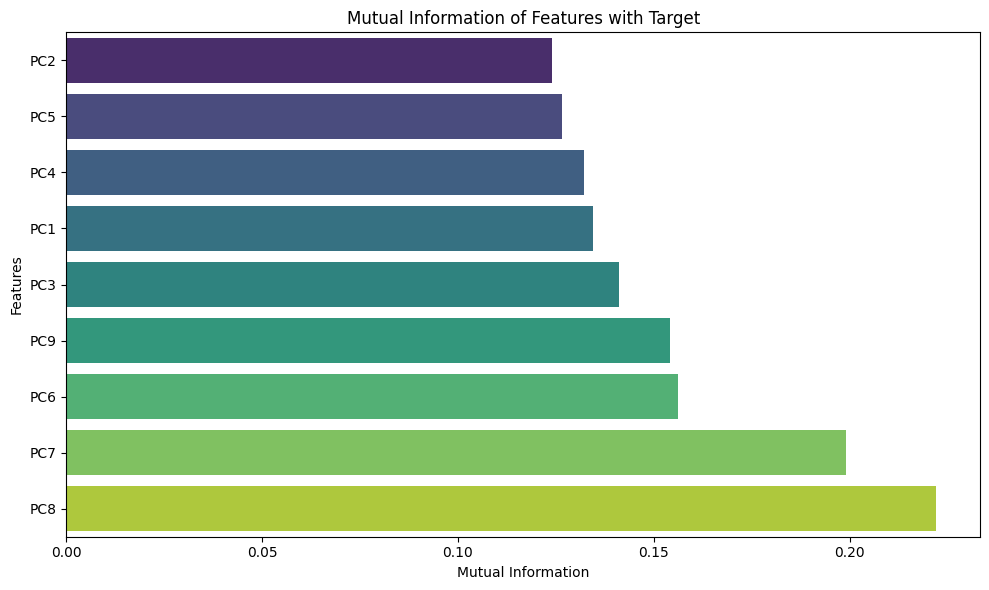

In [38]:
mi = mutual_info_classif(pd.DataFrame(X_pca), y, discrete_features='auto', random_state=42)

mi_df_2 = pd.DataFrame({
    'feature': [f'PC{i+1}' for i in range(n)],
    'mutual_info': mi
}).sort_values(by='mutual_info', ascending=False)

mi_df_2 = mi_df_2.sort_values(by='mutual_info', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='mutual_info', 
    y='feature', 
    data=mi_df_2,
    palette='viridis'
)
plt.title('Mutual Information of Features with Target')
plt.xlabel('Mutual Information')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


Logistic regression

In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)



LogisticRegression(max_iter=1000)

In [47]:
X_train

,hours,weekday,live_cards,used_cards,ev_livecards,ev_usedcards,total_litres,diesel_litres,dd_litres,unleaded_litres,...,rev_E,rev_F,rev_G,rev_H,rev_I,rev_J,dd_margin,msc_fuel,rev_K,fuelonlytranscount
1329,18.0,6.0,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,...,-0.18,3.49,0.00,0.00,0.0,1.50,0.00,0.00,0.0,0.0
1260,10.0,3.0,2.0,2.0,0.0,0.0,745.22,745.22,745.22,0.00,...,0.00,0.00,0.00,0.00,0.0,3.00,7.84,0.00,0.0,11.0
2443,12.0,2.0,2.0,1.0,0.0,0.0,97.69,97.69,0.00,0.00,...,-0.18,6.98,0.00,0.20,0.0,3.00,0.00,1.60,0.0,2.0
2871,8.0,1.0,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.99,0.00,0.00,0.0,0.0
3564,13.0,2.0,6.0,4.0,0.0,0.0,2117.12,1943.20,0.00,173.92,...,0.00,23.94,134.24,4.25,0.0,0.00,0.00,37.70,0.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4965,6.0,2.0,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,...,-0.18,3.49,0.00,0.00,0.0,1.50,0.00,0.00,0.0,0.0
1890,13.0,3.0,5.0,2.0,0.0,0.0,180.61,180.61,0.00,0.00,...,-0.90,17.45,0.00,0.37,0.0,7.50,0.00,3.53,0.0,4.0
2488,8.0,2.0,2.0,1.0,0.0,0.0,148.25,148.25,0.00,0.00,...,-0.36,6.98,0.00,0.17,0.0,3.00,0.00,3.42,0.0,2.0
1845,10.0,0.0,1.0,1.0,0.0,0.0,62.54,62.54,0.00,0.00,...,-0.18,3.49,0.00,0.13,0.0,1.50,0.00,1.15,0.0,1.0


In [53]:
df_new = X_train[:]

df_new['caseid']  = X_train.index

In [54]:
df_new.merge(comp_df, on = 'caseid')

,hours,weekday,live_cards,used_cards,ev_livecards,ev_usedcards,total_litres,diesel_litres,dd_litres,unleaded_litres,...,dd_margin,msc_fuel,rev_K,fuelonlytranscount,caseid,accountid,createddate,closeddate,complaint_reason,complaint_subreason
0,18.0,6.0,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,0.0,1329,4690.0,2024-05-08 13:58:36,2024-05-08 13:58:44,Pricing,Not happy with commercial deal
1,10.0,3.0,2.0,2.0,0.0,0.0,745.22,745.22,745.22,0.00,...,7.84,0.00,0.0,11.0,1260,135.0,2024-08-06 08:15:32,2024-08-06 08:15:32,Credit Team Generated,Fees Only
2,12.0,2.0,2.0,1.0,0.0,0.0,97.69,97.69,0.00,0.00,...,0.00,1.60,0.0,2.0,2443,3233.0,2024-04-24 13:12:44,2024-04-24 13:12:54,Fees,other
3,8.0,1.0,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,0.0,2871,6802.0,2024-09-09 08:53:37,2024-09-09 08:53:37,Credit Team Generated,Fees Only
4,13.0,2.0,6.0,4.0,0.0,0.0,2117.12,1943.20,0.00,173.92,...,0.00,37.70,0.0,39.0,3564,4404.0,2024-08-19 11:06:07,2024-08-21 08:22:36,Refused to engage,UTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3511,6.0,2.0,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,0.0,4965,2568.0,2024-07-26 13:57:11,2024-07-26 13:57:51,Fees,other
3512,13.0,3.0,5.0,2.0,0.0,0.0,180.61,180.61,0.00,0.00,...,0.00,3.53,0.0,4.0,1890,9599.0,2024-04-03 12:43:35,2024-04-03 12:43:45,Client policy,Restructure of business / redundancies
3513,8.0,2.0,2.0,1.0,0.0,0.0,148.25,148.25,0.00,0.00,...,0.00,3.42,0.0,2.0,2488,2579.0,2024-06-06 10:50:21,2024-06-06 13:19:41,Moved to competitor,Other
3514,10.0,0.0,1.0,1.0,0.0,0.0,62.54,62.54,0.00,0.00,...,0.00,1.15,0.0,1.0,1845,11793.0,2024-09-04 14:58:45,NaN,NaN,NaN


In this step, we aim to model the complaint categories we defined earlier using Agglomerative Clustering. For classification modeling, we chose a Random Forest classifier and applied GridSearchCV to find the best hyperparameters. Our evaluation metric is the weighted F1-score, which balances precision and recall across classes while accounting for class disbalance.

The weighted F1-score is particularly important in our case because we did not assign higher importance to one type of complaint over another. For instance, if a complaint is related to a market reason, we can potentially address it by offering discounts or bonuses, making our products more competitive and improving customer satisfaction.

On the other hand, complaints related to internal credit risk might highlight trust or reliability issues in our services. While harder to act on immediately, identifying patterns behind these reasons could help us improve long-term customer retention and product design.

Using machine learning helps us uncover these patterns, prioritize which factors lead to certain complaint types, and potentially simulate the business cost or value of each segment. Even if we can’t act on all issues today, understanding them creates opportunities for future optimization.

In [ ]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced') 


param_grid = {
    'n_estimators': [100,150],
    'max_depth': [7],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [10, 20],
    'max_features': ['log2']
}

scorer = make_scorer(f1_score, average='weighted')

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=7,
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)


Fitting 7 folds for each of 8 candidates, totalling 56 fits
Best parameters: {'max_depth': 7, 'max_features': 'log2', 'min_samples_leaf': 20, 'min_samples_split': 10, 'n_estimators': 150}


In this section, we evaluate how well our model distinguishes between classes. The primary metric used is AUC-ROC, which measures not only the model’s discrimination power but also provides insights into potential overfitting.

Based on the graph, we observe that the model performs similarly on both the training and test sets, suggesting that it likely does not overfit. Moreover, the AUC score of 0.85 on the test set indicates excellent discrimination capability, meaning the model is effective at separating the different complaint categories.

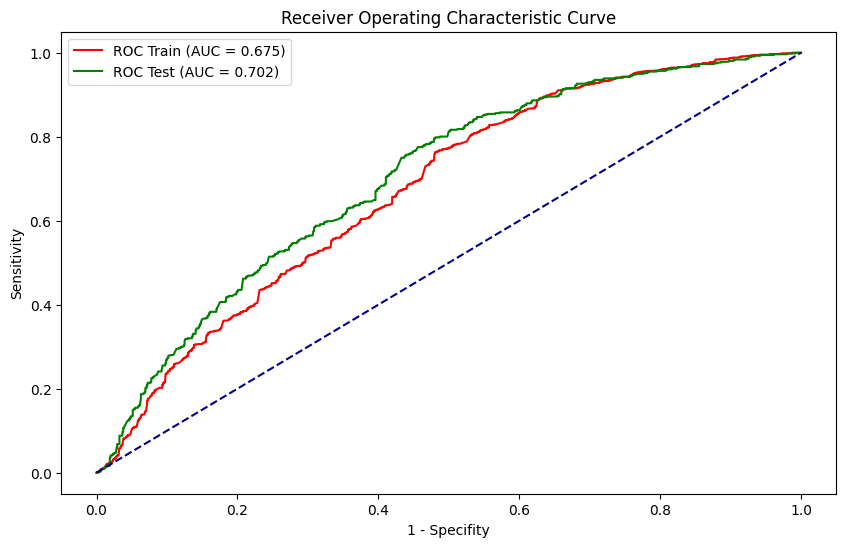

In [49]:
y_pred_log_t = model.predict_proba(X_train)
fpr_t, tpr_t, threshold_t = roc_curve(y_train, y_pred_log_t[:,1])

y_pred_log = model.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_pred_log[:,1])

plt.figure(figsize = (10,6))
plt.plot(fpr_t,tpr_t, color='red', label= f'ROC Train (AUC = {roc_auc_score(y_train, y_pred_log_t[:,1]):.3f})')
plt.plot(fpr,tpr, color='green', label = f'ROC Test (AUC = {roc_auc_score(y_test, y_pred_log[:,1]):.3f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('1 - Specifity')
plt.ylabel('Sensitivity')
plt.title('Receiver Operating Characteristic Curve')
plt.legend()
plt.show()

This section focuses on evaluating our model based on actual classification results. As mentioned earlier, our model should classify classes 0 and 1 evenly and fairly, without bias toward one class. To support this, we adjusted the decision threshold to achieve the best balance between recall and precision.

We selected the threshold that maximized the difference between recall and specificity, aiming for an optimal trade-off between correctly identifying class 0 and class 1.

From the confusion matrix on the test set, we observe the following:

- 808 instances of class 0 were correctly classified.

- 415 instances of class 1 were correctly classified.

- The model misclassified 144 instances of class 0 as class 1 (FP).

- It also misclassified 141 instances of class 1 as class 0 (FN).

These results indicate a fairly balanced classification performance, with a reasonable trade-off between the two types of errors.

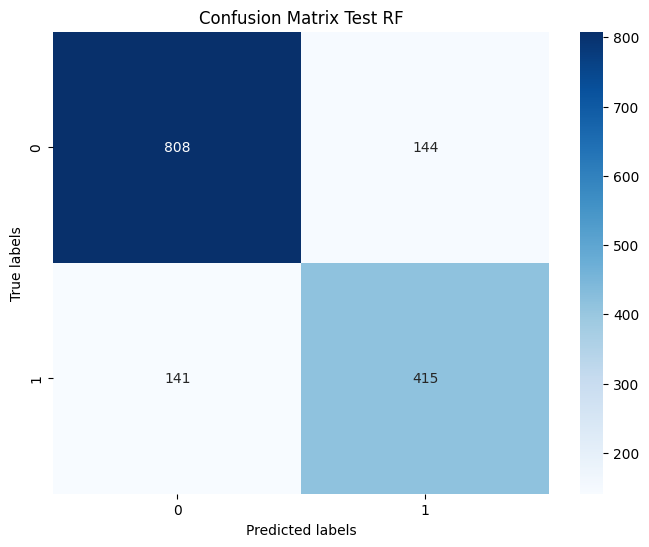

In [ ]:
optimal_idx_t = np.argmax(tpr_t - fpr_t)
optimum_t = threshold_t[optimal_idx_t]

y_pred_actual = (y_pred_log[:,1]>optimum_t)

cm_t = confusion_matrix(y_test, y_pred_actual)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_t, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix Test RF')
plt.show()

To understand the influence of each variable on our model's predictions, we used SHAP values, which allow us to interpret how each feature contributes to the model output. Based on the SHAP summary plot, we observe that PC8 has the most significant impact on the model.

#### PC8 — Seasonal behavior based on time of day
This component is primarily driven by the hours feature, which reflects the time of day. It can be interpreted as a seasonality factor, showing that certain times of day are more associated with customer dissatisfaction. This insight can help us proactively identify when issues tend to occur and explore potential root causes for time-based complaints.

#### PC7 — Weekly seasonality
PC7 also reflects seasonality but emphasizes weekday rather than hour. This suggests that the model is sensitive to weekly patterns, and customer dissatisfaction may vary depending on the day of the week. Together with PC8, this shows that temporal information plays a key role in predicting complaints.

#### PC6 — Usage-related behavior
Although slightly less impactful than PC7 and PC8, PC6 still contributes meaningfully to the model. This component is strongly associated with monthly card usage and transaction volume, indicating that customers with high usage levels are more likely to file a specific type of complaint. This could reflect operational strain or unmet expectations in high-activity users.

#### PC9 — Revenue-related metrics
While not among the top contributors in terms of SHAP impact, PC9 shows high feature values in some cases. It is mainly composed of revenue-related features, particularly rev_A, suggesting that revenue patterns might still influence dissatisfaction for certain customer segments.



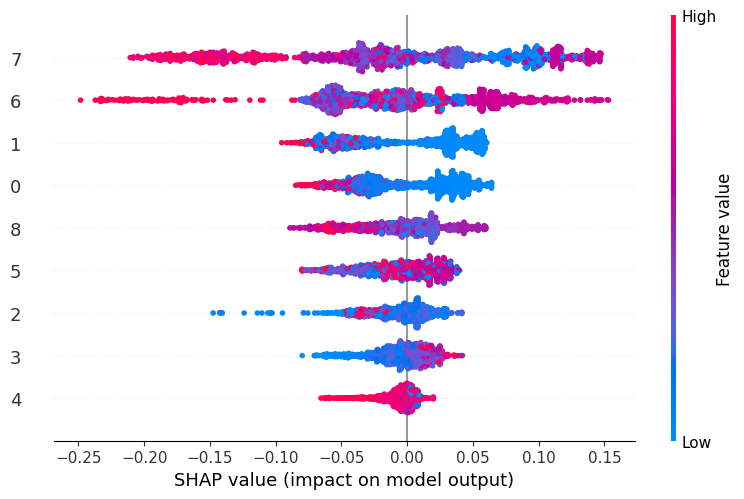

In [ ]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[:, :, 1], X_test)

Here, we want to figure out how each feature impacts our model. We'll do that by linking the importance of the PCA parts from SHAP values with how much the original features load onto those parts. This helps us guess how much each starting variable affects the model, even indirectly through the PCA change.

Like we saw earlier, the hours feature matters most to the model, then weekday. This backs up that time-related habits are key in guessing dissatisfaction.

Next, we'll pick some important variables we've found and check how they're spread across different complaint groups. This should help us make clearer conclusions and spot real patterns behind why customers are unhappy.


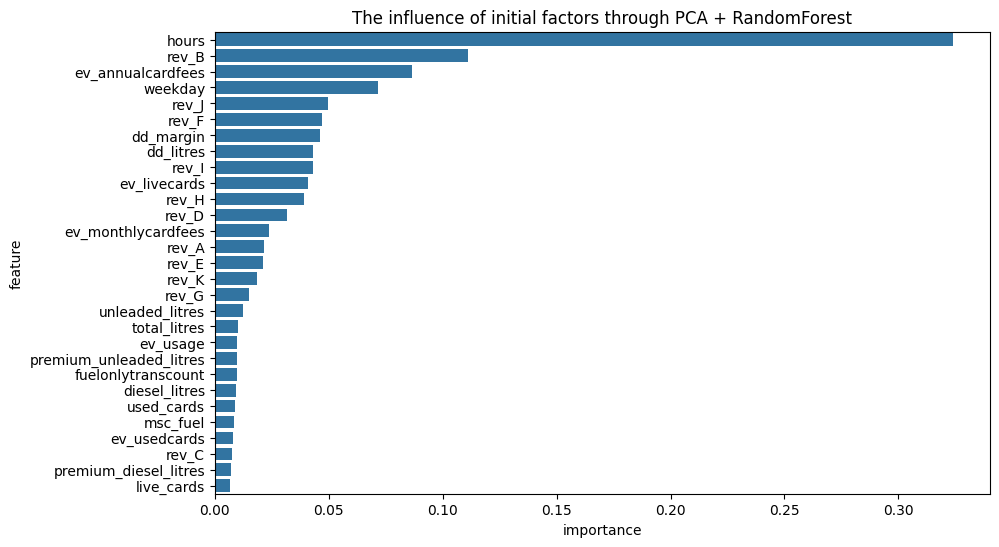

In [ ]:
importances = best_rf.feature_importances_  

components = pca.components_

feature_importance_original = np.abs(importances @ components)

feature_names = X.columns  
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance_original
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title("The influence of initial factors through PCA + RandomForest")
plt.show()

Based on the plot, we observe a clear dependency between the hour of the day and the type of complaint. Specifically, complaints related to internal reasons tend to cluster around 08:00.

This pattern could suggest several underlying causes:

- Operational factors — such as internal system processes or handovers happening around 8 AM

- Customer behavior — for instance, users may submit internal-related complaints before starting their workday or during early morning routines

- Support availability — it's possible that customer support becomes available at this time, prompting more interactions

In any case, this temporal concentration may help improve predictive accuracy, and it also highlights a potential opportunity for root cause analysis within company operations at that specific hour.

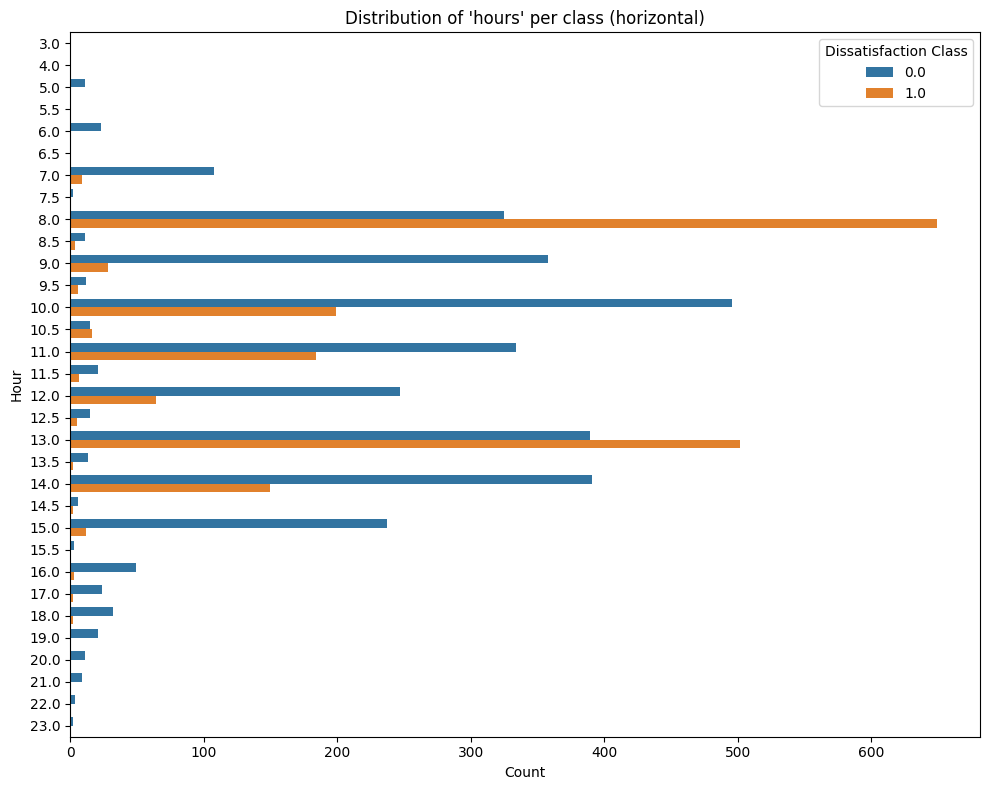

In [ ]:
X['target'] = y

plt.figure(figsize=(10, 8))
sns.countplot(data=X, y='hours', hue='target')  # switched to y
plt.title("Distribution of 'hours' per class (horizontal)")
plt.xlabel("Count")
plt.ylabel("Hour")
plt.legend(title="Dissatisfaction Class")
plt.tight_layout()
plt.show()





Below we can see the bar chart that show us how 

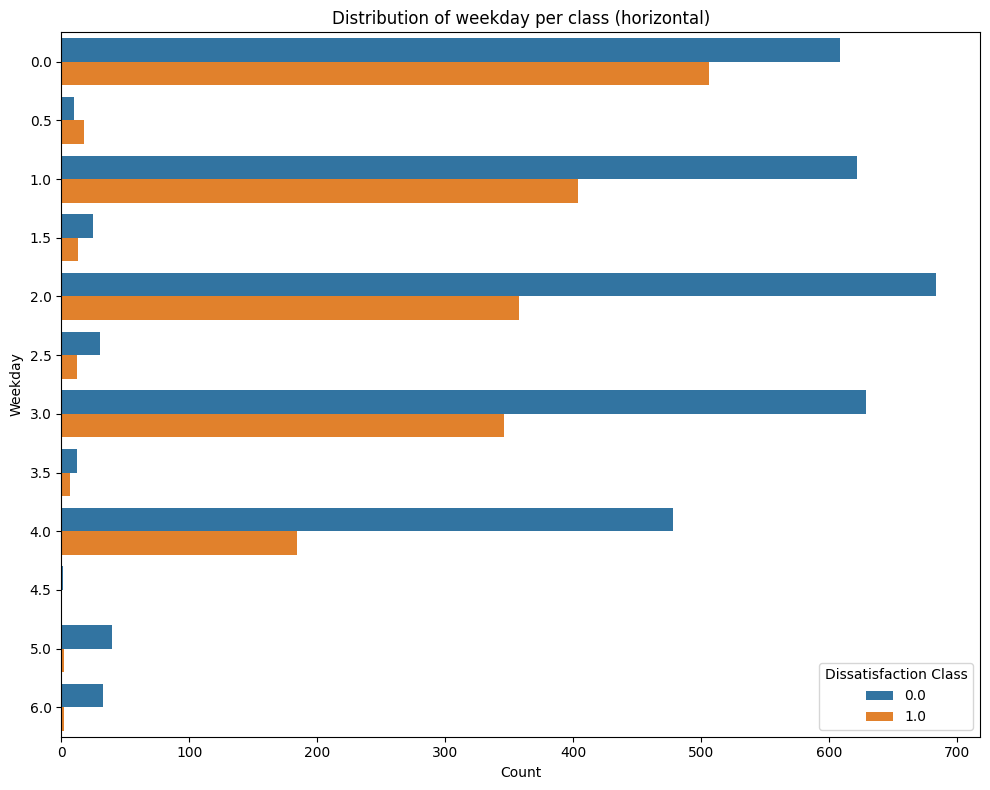

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(data=X, y='weekday', hue='target')  # switched to y
plt.title("Distribution of weekday per class (horizontal)")
plt.xlabel("Count")
plt.ylabel("Weekday")
plt.legend(title="Dissatisfaction Class")
plt.tight_layout()
plt.show()


In [ ]:
def plot_trimmed_distributions_mod(series1, series2, col_name, label1 = '0', label2 = '1', alpha= 0.5):

    s1 = np.asarray(series1)
    s2 = np.asarray(series2)

    # 95% confidence interval
    if len(s1) < 2 or len(s2) < 2:
        return  # skip if not enough data

    low1, high1 = np.percentile(s1, [2.5, 97.5])
    low2, high2 = np.percentile(s2, [2.5, 97.5])

    trimmed1 = s1[(s1 >= low1) & (s1 <= high1)]
    trimmed2 = s2[(s2 >= low2) & (s2 <= high2)]

    plt.figure(figsize=(6, 3))

    sns.kdeplot(trimmed1, label=label1, color='steelblue', fill=True, alpha=alpha, linewidth=2)
    sns.kdeplot(trimmed2, label=label2, color='darkorange', fill=True, alpha=alpha, linewidth=2)

    plt.title(f'{col_name} by class (95% interval)')
    plt.tight_layout()
    plt.legend()
    plt.show()


Since rev_D might reflect some type of revenue or score, this could mean that complaints of internal reason tend to occur when this metric is very low — a sign worth investigating operationally.


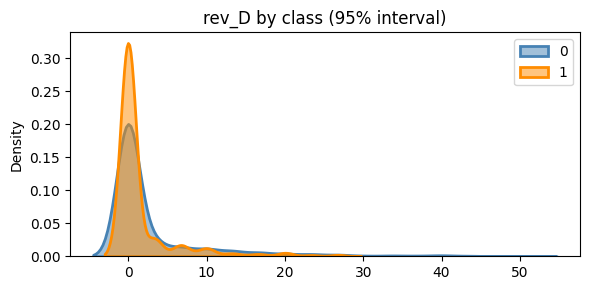

In [ ]:
plot_trimmed_distributions_mod(X.loc[y == 0]['rev_D'], X.loc[y == 1]['rev_D'], col_name = 'rev_D')


In [ ]:
X.columns

Index(['hours', 'weekday', 'live_cards', 'used_cards', 'ev_livecards',
       'ev_usedcards', 'total_litres', 'diesel_litres', 'dd_litres',
       'unleaded_litres', 'premium_diesel_litres', 'premium_unleaded_litres',
       'ev_usage', 'ev_annualcardfees', 'ev_monthlycardfees', 'rev_A', 'rev_B',
       'rev_C', 'rev_D', 'rev_E', 'rev_F', 'rev_G', 'rev_H', 'rev_I', 'rev_J',
       'dd_margin', 'msc_fuel', 'rev_K', 'fuelonlytranscount', 'target'],
      dtype='object')

For the variable dd_margin, we observe a clear pattern in its distribution across complaint types.
Specifically, the distribution for internal reasons is more peaked (higher kurtosis) compared to that for market-related reasons.

This means that when the dd_margin is close to 0, the complaint is more likely to be associated with an internal issue rather than a market-related one.

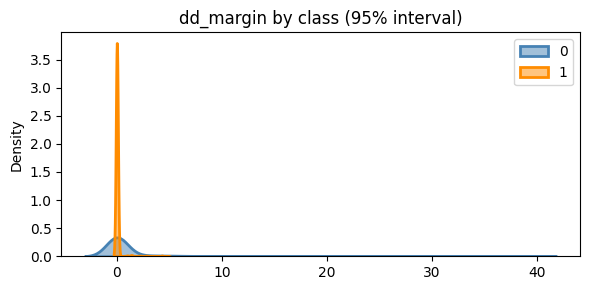

In [ ]:
plot_trimmed_distributions_mod(X.loc[y == 0]['dd_margin'], X.loc[y == 1]['dd_margin'], col_name = 'dd_margin')


The distribution of dd_litres also reveals a useful pattern:
Class 1 shows higher kurtosis compared to Class 0, meaning its values are more concentrated around the center. In particular, when dd_litres is close to 0, the data point is more likely to belong to Class 1. This makes dd_litres another potentially informative feature for distinguishing between the two types of dissatisfaction.

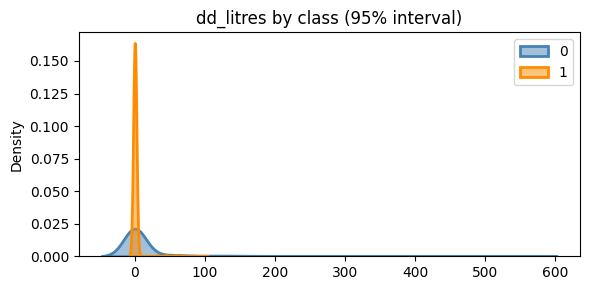

In [ ]:
plot_trimmed_distributions_mod(X.loc[y == 0]['dd_litres'], X.loc[y == 1]['dd_litres'], col_name = 'dd_litres')

Here you can check the distribution among classes for every components.

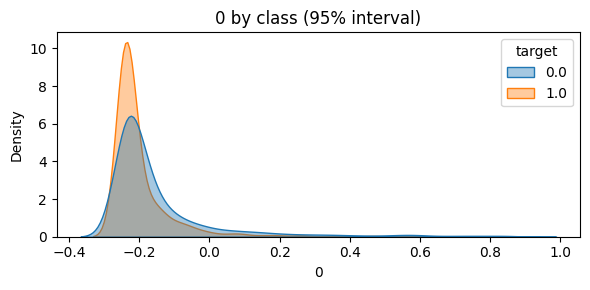

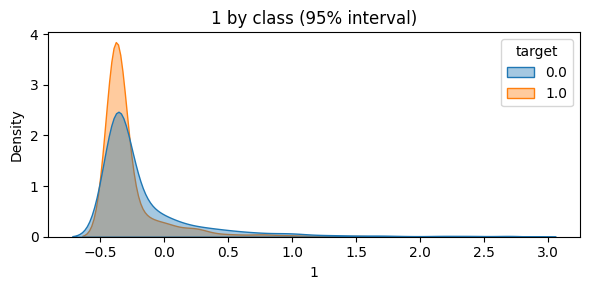

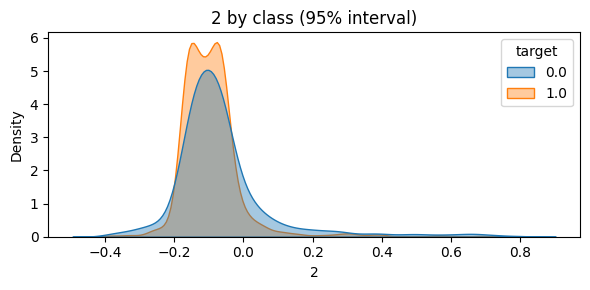

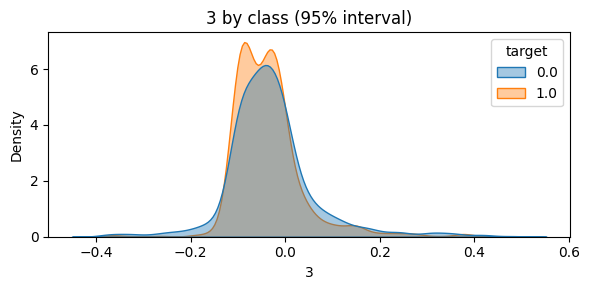

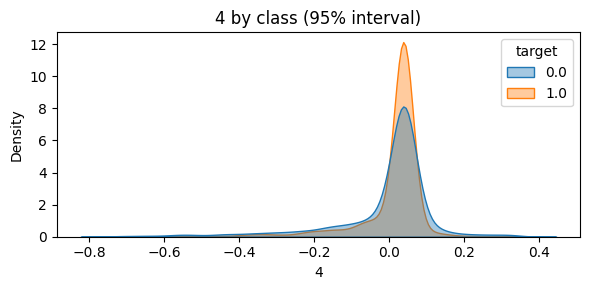

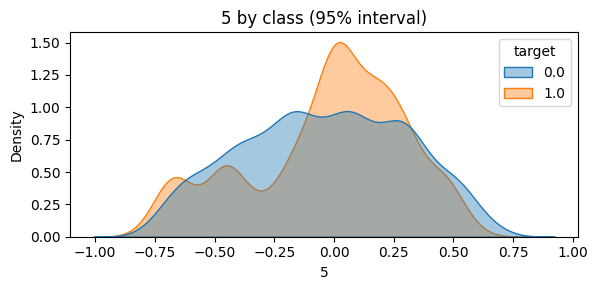

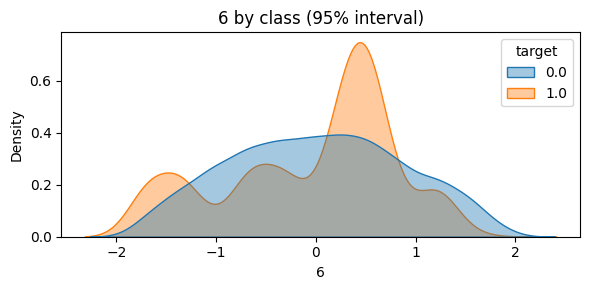

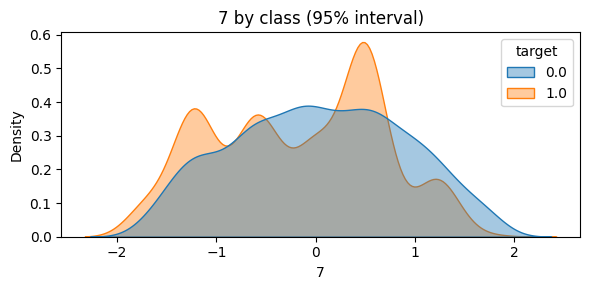

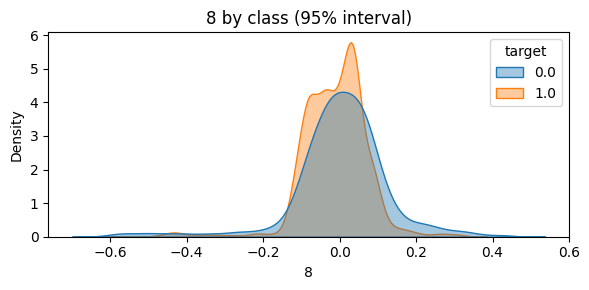

In [ ]:


for col in X_pca.columns:
    
    temp_df = pd.DataFrame({col: X_train[col], 'target': y_train})

    lower, upper = np.percentile(temp_df[col], [2.5, 97.5])
    trimmed_df = temp_df[(temp_df[col] >= lower) & (temp_df[col] <= upper)]

    plt.figure(figsize=(6, 3))
    sns.kdeplot(data=trimmed_df, x=col, hue='target', common_norm=False, fill=True, alpha=0.4)
    plt.title(f'{col} by class (95% interval)')
    plt.tight_layout()
    plt.show()


## Conclusion

To enhance the effectiveness of our analysis and address data imbalances, complaints were categorized into two main groups:

1. **Internal Causes** (e.g., credit policy)
2. **Customer and Market Factors**

This categorization improves classification accuracy and enables the development of targeted strategies for handling different types of complaints.

We identified two significant peaks in complaint volume—at 8:00 a.m. and 1:00 p.m. Possible explanations for these peaks include:

- The beginning of the workday and the opening of customer service.
- Lunchtime, when customers have the opportunity to reach out for assistance.

These patterns may reflect customer behavior and potential internal disruptions during these hours.

Utilizing the Random Forest model yielded an AUC-ROC of approximately 0.85, indicating a strong ability to distinguish between types of complaints. Currently, the model performs binary classification, differentiating complaints related to internal causes (e.g., credit policy) from those stemming from external factors (market, customer behavior, etc.).

The model allows us to:

- Predict the company's potential responsibility regarding complaints.
- Prioritize complaints that are directly impacted by internal processes.
- Identify customers at an increased risk of contacting the company for internal reasons before problems arise.

By employing dimensionality reduction techniques (PCA) and model interpretation (SHAP), we identified the key features influencing complaints. The most significant factors were:

- Time variables (hour, weekday)
- Usage indicators (e.g., `ev_usage`, `dd_margin`, `rev_B`)

To optimize support service performance during peak hours, we recommend the following:

- Increase staffing levels.
- Introduce automated processing scenarios or chatbots.
- Analyze internal processes, especially those related to morning and lunch breaks, to identify potential bottlenecks.
- Develop targeted complaint handling strategies for both internal and market-related causes.
- Integrate a machine learning model into operational processes for early warnings and automated responses to potential complaints.
- Continue analyzing key factors—such as card usage, contact times, and turnover metrics—and leverage this knowledge to enhance the customer experience.

Customers with high card usage and significant monthly transactions are more likely to generate specific types of complaints.

